
# 📕 บทที่ 07 — Polarimetric QC, KDP, Attenuation Correction และ HID
### หลักสูตรแลปเรดาร์ตรวจอากาศด้วย Py-ART และไลบรารีรหัสเปิด

**ระดับ:** ขั้นสูง  
**ต้องมีก่อน:** รันบทที่ 00 เพื่อเตรียม Course Workspace และควรผ่านบทที่ 02–06

Notebook นี้ใช้ข้อมูลที่ Notebook 00 เตรียมไว้เท่านั้น:

```python
P.RADAR_1000
P.SOUNDING
P.results_dir("lesson07")
```

ไม่มีการดาวน์โหลดข้อมูลเรดาร์หรือ sounding เพิ่มเติม

---

## วัตถุประสงค์การเรียนรู้

เมื่อจบบทนี้ นิสิตจะสามารถ

- ตรวจสอบความพร้อมและคุณภาพของฟิลด์ dual-polarization
- อธิบายความหมายของ \(Z_H\), \(Z_{DR}\), \(\Phi_{DP}\), \(\rho_{HV}\) และ \(K_{DP}\)
- สร้าง polarimetric GateFilter และ Boolean QC mask
- ตรวจ transition, discontinuity และ local variability ของ \(\Phi_{DP}\)
- unwrap และ smooth \(\Phi_{DP}\) ตามแนวลำบีม
- ประมาณ \(K_{DP}\) ด้วย local derivative/regression workflow
- ทดลอง Maesaka variational KDP ของ Py-ART เป็นทางเลือก
- นำ sounding temperature profile ไป map ลงบน radar gates
- ประมาณระดับ 0, −10, −20 และ −30 °C
- แก้ attenuation ของ \(Z_H\) และ \(Z_{DR}\) ด้วย Py-ART Z–PHI
- ใช้ fallback แบบ PHIDP-linear เมื่อ Z–PHI ไม่สามารถทำงานกับข้อมูลตัวอย่าง
- จำแนก hydrometeor ด้วย `hydroclass_semisupervised`
- ประเมิน entropy และสัดส่วน hydrometeor classes
- ส่งออก processed radar เป็น CF/Radial NetCDF พร้อม diagnostic tables

> **ข้อควรระวัง:** ผลจาก Notebook นี้เป็น workflow สำหรับการเรียนและการตรวจสอบขั้นต้น ไม่ควรนำไปตีพิมพ์โดยไม่ตรวจ calibration, system phase, ZDR bias, radar frequency, melting layer, attenuation coefficients และความเหมาะสมของ membership functions สำหรับเรดาร์ PHS



## ⚠️ Sounding ที่ใช้เป็นข้อมูลสาธิต

ไฟล์ `P.SOUNDING` คือ sounding สถานีเชียงใหม่ VTCC เวลา 00 UTC วันที่ 24 เมษายน 2021 ขณะที่ข้อมูลเรดาร์ PHS เป็นวันที่ 20 กรกฎาคม 2018

ดังนั้น sounding นี้ใช้เพื่อสาธิต

- การอ่าน vertical profile
- การหา isotherm heights
- การ map temperature ลงบน radar gates
- การเรียก HID algorithm

แต่ **ไม่ใช่ sounding ที่ตรงเวลาและตรงพื้นที่กับเหตุการณ์เรดาร์** และห้ามใช้สรุปสภาพแวดล้อมจริงของเหตุการณ์ PHS



## 🧠 1. หลักการ Polarimetric Radar

### Reflectivity \(Z_H\)

แสดงกำลังสะท้อนของ hydrometeors ใน horizontal polarization หน่วย dBZ

### Differential reflectivity \(Z_{DR}\)

\[
Z_{DR}=10\log_{10}\left(\frac{Z_H}{Z_V}\right)
\]

ใช้บ่งชี้รูปร่างและ orientation โดยเฉลี่ยของ hydrometeors แต่ต้องตรวจ ZDR calibration bias ก่อนใช้งานเชิงปริมาณ

### Copolar correlation coefficient \(\rho_{HV}\)

แสดงความคล้ายกันของสัญญาณ horizontal และ vertical

- ใกล้ 1: hydrometeor population ค่อนข้างสม่ำเสมอ
- ลดลง: mixed phase, melting, hail, non-meteorological echo, weak signal หรือ sampling problems

ค่าต่ำไม่ได้แปลว่า clutter เสมอไป

### Differential phase \(\Phi_{DP}\)

เป็น cumulative phase difference ตามแนวลำบีม หน่วยองศา ประกอบด้วย

\[
\Psi_{DP}=\Phi_{DP}+\delta
\]

โดย \(\delta\) คือ backscatter differential phase

### Specific differential phase \(K_{DP}\)

\[
K_{DP}
=
\frac{1}{2}
\frac{d\Phi_{DP}}{dr}
\]

หน่วย deg km\(^{-1}\)

\(K_{DP}\) มีประโยชน์ในฝนหนักเพราะไม่ไวต่อ absolute calibration ของ reflectivity และได้รับผลจาก attenuation น้อยกว่า \(Z_H\)

### Attenuation correction

เรดาร์ C-band อาจสูญเสียพลังงานเมื่อคลื่นผ่านฝนหนัก ทำให้ echo ด้านหลังพายุมี \(Z_H\) ต่ำกว่าความเป็นจริง การแก้ attenuation ต้องอาศัย phase consistency และ QC ที่ดี

### Hydrometeor Identification — HID

HID ใช้ตัวแปรหลายชนิดร่วมกัน เช่น

\[
Z_H,\ Z_{DR},\ K_{DP},\ \rho_{HV},\ T
\]

เพื่อจำแนกประเภท hydrometeor แบบ fuzzy หรือ semi-supervised ไม่ใช่การสังเกตชนิดอนุภาคโดยตรง



## 🗂️ 2. กระบวนการของบทนี้

1. ติดตั้งไลบรารีและ Mount Google Drive
2. import `course_paths as P`
3. อ่าน `P.RADAR_1000` และ `P.SOUNDING`
4. ตรวจ field names, units, valid fraction และ percentile
5. สร้าง polarimetric QC mask
6. unwrap และ smooth PHIDP
7. คำนวณ PHIDP local standard deviation
8. ประมาณ KDP แบบ local derivative
9. ทดลอง Py-ART Maesaka KDP เมื่อเปิดใช้งาน
10. อ่าน sounding และหา isotherm heights
11. map temperature ลง radar gates
12. ทำ Z–PHI attenuation correction
13. ทำ HID และ entropy
14. สร้าง PPI, ray diagnostics, tables และ processed CF/Radial
15. บันทึกผลใน `P.results_dir("lesson07")`

**เอกสารอ้างอิงหลัก**

- Py-ART `kdp_maesaka`  
  https://arm-doe.github.io/pyart/API/generated/pyart.retrieve.kdp_maesaka.html
- Py-ART `calculate_attenuation_zphi`  
  https://arm-doe.github.io/pyart/API/generated/pyart.correct.calculate_attenuation_zphi.html
- Py-ART `map_profile_to_gates`  
  https://arm-doe.github.io/pyart/API/generated/pyart.retrieve.map_profile_to_gates.html
- Py-ART `hydroclass_semisupervised`  
  https://arm-doe.github.io/pyart/API/generated/pyart.retrieve.hydroclass_semisupervised.html



## ⚙️ 3. ติดตั้งไลบรารีและเชื่อม Course Workspace


In [ ]:
#@title ติดตั้งไลบรารี
%pip install -q "arm-pyart==2.2.5" scipy pandas matplotlib netCDF4 psutil

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.9/203.9 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.8/157.8 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 42.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the sour

In [ ]:
#@title Mount Drive และโหลด course_paths.py
from __future__ import annotations

import copy
import importlib
import json
import os
import shutil
import sys
import time
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import pyart

from matplotlib.colors import BoundaryNorm, ListedColormap
from scipy.ndimage import median_filter
from scipy.signal import savgol_filter

warnings.filterwarnings("ignore")

from google.colab import drive
drive.mount("/content/drive")

ROOT = "/content/drive/MyDrive/tmd_radar_course"
CONFIG_DIR = os.path.join(ROOT, "9config")

if CONFIG_DIR not in sys.path:
    sys.path.append(CONFIG_DIR)

try:
    import course_paths as P
    importlib.reload(P)
except Exception as error:
    raise RuntimeError(
        "ไม่สามารถ import course_paths.py ได้ "
        "กรุณารัน Notebook 00 ให้สำเร็จก่อน"
    ) from error

required_paths = {
    "Radar 10:00": P.RADAR_1000,
    "Sounding": P.SOUNDING,
}

missing = [
    f"{name}: {path}"
    for name, path in required_paths.items()
    if not path or not os.path.exists(path)
]
if missing:
    raise FileNotFoundError(
        "ข้อมูลจาก Notebook 00 ยังไม่ครบ:\n"
        + "\n".join(missing)
        + "\nกรุณากลับไปรัน Notebook 00"
    )

LESSON07_DIR = Path(P.results_dir("lesson07"))
FIGURE_DIR = LESSON07_DIR / "figures"
CSV_DIR = LESSON07_DIR / "csv"
NETCDF_DIR = LESSON07_DIR / "netcdf"
DIAGNOSTIC_DIR = LESSON07_DIR / "diagnostics"

for directory in [
    FIGURE_DIR,
    CSV_DIR,
    NETCDF_DIR,
    DIAGNOSTIC_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

LOCAL_ROOT = Path("/content/tmd_radar_course/lesson07")
LOCAL_DATA = LOCAL_ROOT / "data"
LOCAL_OUTPUT = LOCAL_ROOT / "outputs"

LOCAL_DATA.mkdir(parents=True, exist_ok=True)
LOCAL_OUTPUT.mkdir(parents=True, exist_ok=True)

LOCAL_RADAR = LOCAL_DATA / Path(P.RADAR_1000).name
LOCAL_SOUNDING = LOCAL_DATA / Path(P.SOUNDING).name

for source, destination in [
    (Path(P.RADAR_1000), LOCAL_RADAR),
    (Path(P.SOUNDING), LOCAL_SOUNDING),
]:
    if (
        not destination.exists()
        or destination.stat().st_size
        != source.stat().st_size
    ):
        shutil.copy2(source, destination)

print("Py-ART version :", pyart.__version__)
print("Course root    :", P.ROOT)
print("Radar          :", P.RADAR_1000)
print("Sounding       :", P.SOUNDING)
print("Lesson07 output:", LESSON07_DIR)
print("RAM available  :", f"{psutil.virtual_memory().available / 1e9:.2f} GB")
print("พร้อมเริ่มบทที่ 07 ✅")


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly supported
## by the U.S. Department of Energy Office of Science as part of
## the Atmospheric Radiation Measurement (ARM) User Facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119

Mounted at /content/drive
Py-ART version : 2.2.5
Course root    : /content/drive/MyDrive/tmd_radar_course
Radar          : /content/drive/MyDrive/tmd_radar_course/0data/radar/PHS240@201807201000.uf.bz2
Sounding       : /content/drive/MyDrive/tmd_radar_course/0data/sounding/sounding_cm.txt
Lesson07 output: /content/drive/MyDrive/tmd_radar_course/1results/lesson07
RAM available  : 11.94 GB
พร้อมเริ่มบทที่ 07 ✅



## 🔤 4. ตั้งค่าฟอนต์ไทยและรูปแบบภาพ


In [ ]:
#@title ตั้งค่าฟอนต์ไทย
import glob
import subprocess
import urllib.request
import matplotlib.font_manager as fm

def setup_thai_font(verbose: bool = True) -> str | None:
    font_dir = Path("/usr/share/fonts/truetype/sarabun")
    font_dir.mkdir(parents=True, exist_ok=True)

    if not list(font_dir.glob("*.ttf")):
        base_url = "https://github.com/google/fonts/raw/main/ofl/sarabun/"
        for filename in ("Sarabun-Regular.ttf", "Sarabun-Bold.ttf"):
            try:
                urllib.request.urlretrieve(
                    base_url + filename,
                    font_dir / filename,
                )
            except Exception:
                pass

    if (
        not list(font_dir.glob("*.ttf"))
        and not glob.glob("/usr/share/fonts/truetype/tlwg/*.ttf")
    ):
        subprocess.run(
            ["apt-get", "-qq", "-y", "install", "fonts-thai-tlwg"],
            capture_output=True,
        )

    font_paths = (
        list(font_dir.glob("*.ttf"))
        + [Path(path) for path in glob.glob(
            "/usr/share/fonts/truetype/tlwg/*.ttf"
        )]
    )
    for font_path in font_paths:
        try:
            fm.fontManager.addfont(str(font_path))
        except Exception:
            pass

    available = {font.name for font in fm.fontManager.ttflist}
    chosen = next(
        (
            name
            for name in ("Sarabun", "Loma", "Garuda", "Norasi")
            if name in available
        ),
        None,
    )

    if chosen:
        mpl.rcParams["font.family"] = chosen

    mpl.rcParams["axes.unicode_minus"] = False

    if verbose:
        print("ฟอนต์ไทยที่ใช้:", chosen or "ไม่พบฟอนต์ไทย")
    return chosen

setup_thai_font()

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 13,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.unicode_minus": False,
})

REF_CMAP = (
    "pyart_NWSRef"
    if "pyart_NWSRef" in plt.colormaps()
    else "NWSRef"
    if "NWSRef" in plt.colormaps()
    else "turbo"
)

PHASE_CMAP = "twilight"
RHOHV_CMAP = "viridis"
ZDR_CMAP = "coolwarm"
KDP_CMAP = "turbo"

print("Reflectivity colormap:", REF_CMAP)

ฟอนต์ไทยที่ใช้: Sarabun
Reflectivity colormap: NWSRef



## 📡 5. อ่าน Radar object และตรวจฟิลด์ dual-pol

ชื่อฟิลด์แตกต่างกันได้ตาม format และผู้ผลิต จึงใช้ alias resolver แทนการ hard-code

ฟิลด์หลักที่ต้องการ:

- Reflectivity
- Differential reflectivity
- Differential phase
- Cross-correlation ratio
- Hardware KDP ถ้ามี

หากขาด ZDR, PHIDP หรือ RHOHV ระบบจะหยุดพร้อมรายชื่อฟิลด์จริง เพราะ HID และ attenuation ไม่ควรสร้างจากข้อมูลที่ไม่ครบ


In [ ]:
#@title อ่าน Radar object และค้นหาฟิลด์
radar = pyart.io.read(str(LOCAL_RADAR))

FIELD_ALIASES = {
    "reflectivity": [
        "reflectivity",
        "corrected_reflectivity",
        "DBZ",
        "DZ",
        "ZH",
    ],
    "zdr": [
        "differential_reflectivity",
        "corrected_differential_reflectivity",
        "ZDR",
        "DR",
    ],
    "phidp": [
        "differential_phase",
        "corrected_differential_phase",
        "uncorrected_differential_phase",
        "PHIDP",
        "PHI",
    ],
    "rhohv": [
        "cross_correlation_ratio",
        "corrected_cross_correlation_ratio",
        "uncorrected_cross_correlation_ratio",
        "RHOHV",
        "RHV",
        "CC",
    ],
    "kdp_hardware": [
        "specific_differential_phase",
        "corrected_specific_differential_phase",
        "KDP",
    ],
}

def find_field(
    radar_object,
    candidates: list[str],
    *,
    required: bool = False,
) -> str | None:
    available = list(radar_object.fields)
    lookup = {
        name.lower(): name
        for name in available
    }

    for candidate in candidates:
        if candidate.lower() in lookup:
            return lookup[candidate.lower()]

    if required:
        raise KeyError(
            f"ไม่พบฟิลด์จาก candidates={candidates}\n"
            f"ฟิลด์ที่มีจริงคือ {available}"
        )
    return None

REFLECTIVITY = find_field(
    radar,
    FIELD_ALIASES["reflectivity"],
    required=True,
)
ZDR = find_field(
    radar,
    FIELD_ALIASES["zdr"],
    required=True,
)
PHIDP_RAW = find_field(
    radar,
    FIELD_ALIASES["phidp"],
    required=True,
)
RHOHV = find_field(
    radar,
    FIELD_ALIASES["rhohv"],
    required=True,
)
HARDWARE_KDP = find_field(
    radar,
    FIELD_ALIASES["kdp_hardware"],
)

RADAR_LAT = float(radar.latitude["data"][0])
RADAR_LON = float(radar.longitude["data"][0])
RADAR_ALT_MSL_M = float(radar.altitude["data"][0])
RANGE_KM = np.asarray(
    radar.range["data"],
    dtype=float,
) / 1000.0
GATE_SPACING_KM = float(
    np.nanmedian(np.diff(RANGE_KM))
)

SELECTED_FIELDS = {
    "reflectivity": REFLECTIVITY,
    "differential_reflectivity": ZDR,
    "differential_phase": PHIDP_RAW,
    "cross_correlation_ratio": RHOHV,
    "hardware_kdp": HARDWARE_KDP,
}

print("Radar location :", f"{RADAR_LAT:.5f}, {RADAR_LON:.5f}")
print("Radar altitude :", f"{RADAR_ALT_MSL_M:.1f} m MSL")
print("Sweeps         :", radar.nsweeps)
print("Rays × gates   :", radar.nrays, "×", radar.ngates)
print("Gate spacing   :", f"{GATE_SPACING_KM:.3f} km")
print("Fixed angles   :", np.round(radar.fixed_angle["data"], 2).tolist())
print("\nSelected fields:")
for label, field_name in SELECTED_FIELDS.items():
    print(f"  {label:30s}: {field_name}")

Radar location : 16.77541, 100.21796
Radar altitude : 72.0 m MSL
Sweeps         : 4
Rays × gates   : 1924 × 240
Gate spacing   : 1.000 km
Fixed angles   : [0.47999998927116394, 1.4800000190734863, 2.390000104904175, 3.390000104904175]

Selected fields:
  reflectivity                  : reflectivity
  differential_reflectivity     : corrected_differential_reflectivity
  differential_phase            : differential_phase
  cross_correlation_ratio       : cross_correlation_ratio
  hardware_kdp                  : None


In [ ]:
#@title Field inventory และ percentile diagnostics
def summarize_field(
    radar_object,
    field_name: str,
) -> dict:
    data = np.ma.asarray(
        radar_object.fields[field_name]["data"]
    )
    values = np.asarray(
        data.compressed(),
        dtype=float,
    )
    values = values[
        np.isfinite(values)
    ]

    row = {
        "field": field_name,
        "units": radar_object.fields[field_name].get(
            "units",
            "",
        ),
        "total_gates": int(data.size),
        "valid_gates": int(values.size),
        "valid_fraction_pct": float(
            100 * values.size / data.size
        ),
    }

    if values.size:
        for label, percentile in [
            ("minimum", 0),
            ("p01", 1),
            ("p05", 5),
            ("median", 50),
            ("p95", 95),
            ("p99", 99),
            ("maximum", 100),
        ]:
            row[label] = float(
                np.nanpercentile(
                    values,
                    percentile,
                )
            )
    return row

field_inventory = pd.DataFrame([
    summarize_field(radar, field_name)
    for field_name in SELECTED_FIELDS.values()
    if field_name is not None
])

display(field_inventory.round(3))

field_inventory.to_csv(
    CSV_DIR / "polarimetric_field_inventory.csv",
    index=False,
    encoding="utf-8-sig",
)

,field,units,total_gates,valid_gates,valid_fraction_pct,minimum,p01,p05,median,p95,p99,maximum
0,reflectivity,dBZ,461760,113273,24.531,-17.50,-12.00,-6.00,15.50,35.00,53.00,83.5
1,corrected_differential_reflectivity,dB,461760,455988,98.750,-15.91,-11.67,-8.28,0.00,4.14,7.81,8.0
2,differential_phase,degrees,461760,455988,98.750,-178.59,-174.35,-146.12,95.29,157.41,174.35,180.0
3,cross_correlation_ratio,ratio,461760,461760,100.000,0.00,0.00,0.08,0.26,0.91,0.97,1.0



## 📊 6. PPI ของฟิลด์ dual-pol ก่อน QC

ใช้ sweep ต่ำสุดเพื่อสำรวจ

- โครงสร้าง \(Z_H\)
- bias หรือ outlier ของ \(Z_{DR}\)
- discontinuity ของ \(\Phi_{DP}\)
- พื้นที่ \(\rho_{HV}\) ต่ำ

สีและช่วงค่าคงที่เพื่อให้เปรียบเทียบได้

> **หมายเหตุเรื่องแผนที่:** บทนี้ใช้ `pyart.graph.RadarDisplay` แบบพิกัด Cartesian สัมพัทธ์กับเรดาร์ (ไม่ใช่ geographic/UTM ตาม helper ของบทที่ 06) เพราะโฟกัสอยู่ที่ระดับ gate/ray สำหรับงาน QC และ retrieval หากต้องการแผนที่ระดับตีพิมพ์พร้อมพิกัดภูมิศาสตร์ ให้นำฟิลด์ที่ผ่านบทนี้ (เช่น `corrected_reflectivity_zphi`, `hydroclass`) ไปพล็อตต่อด้วย helper จากบทที่ 06


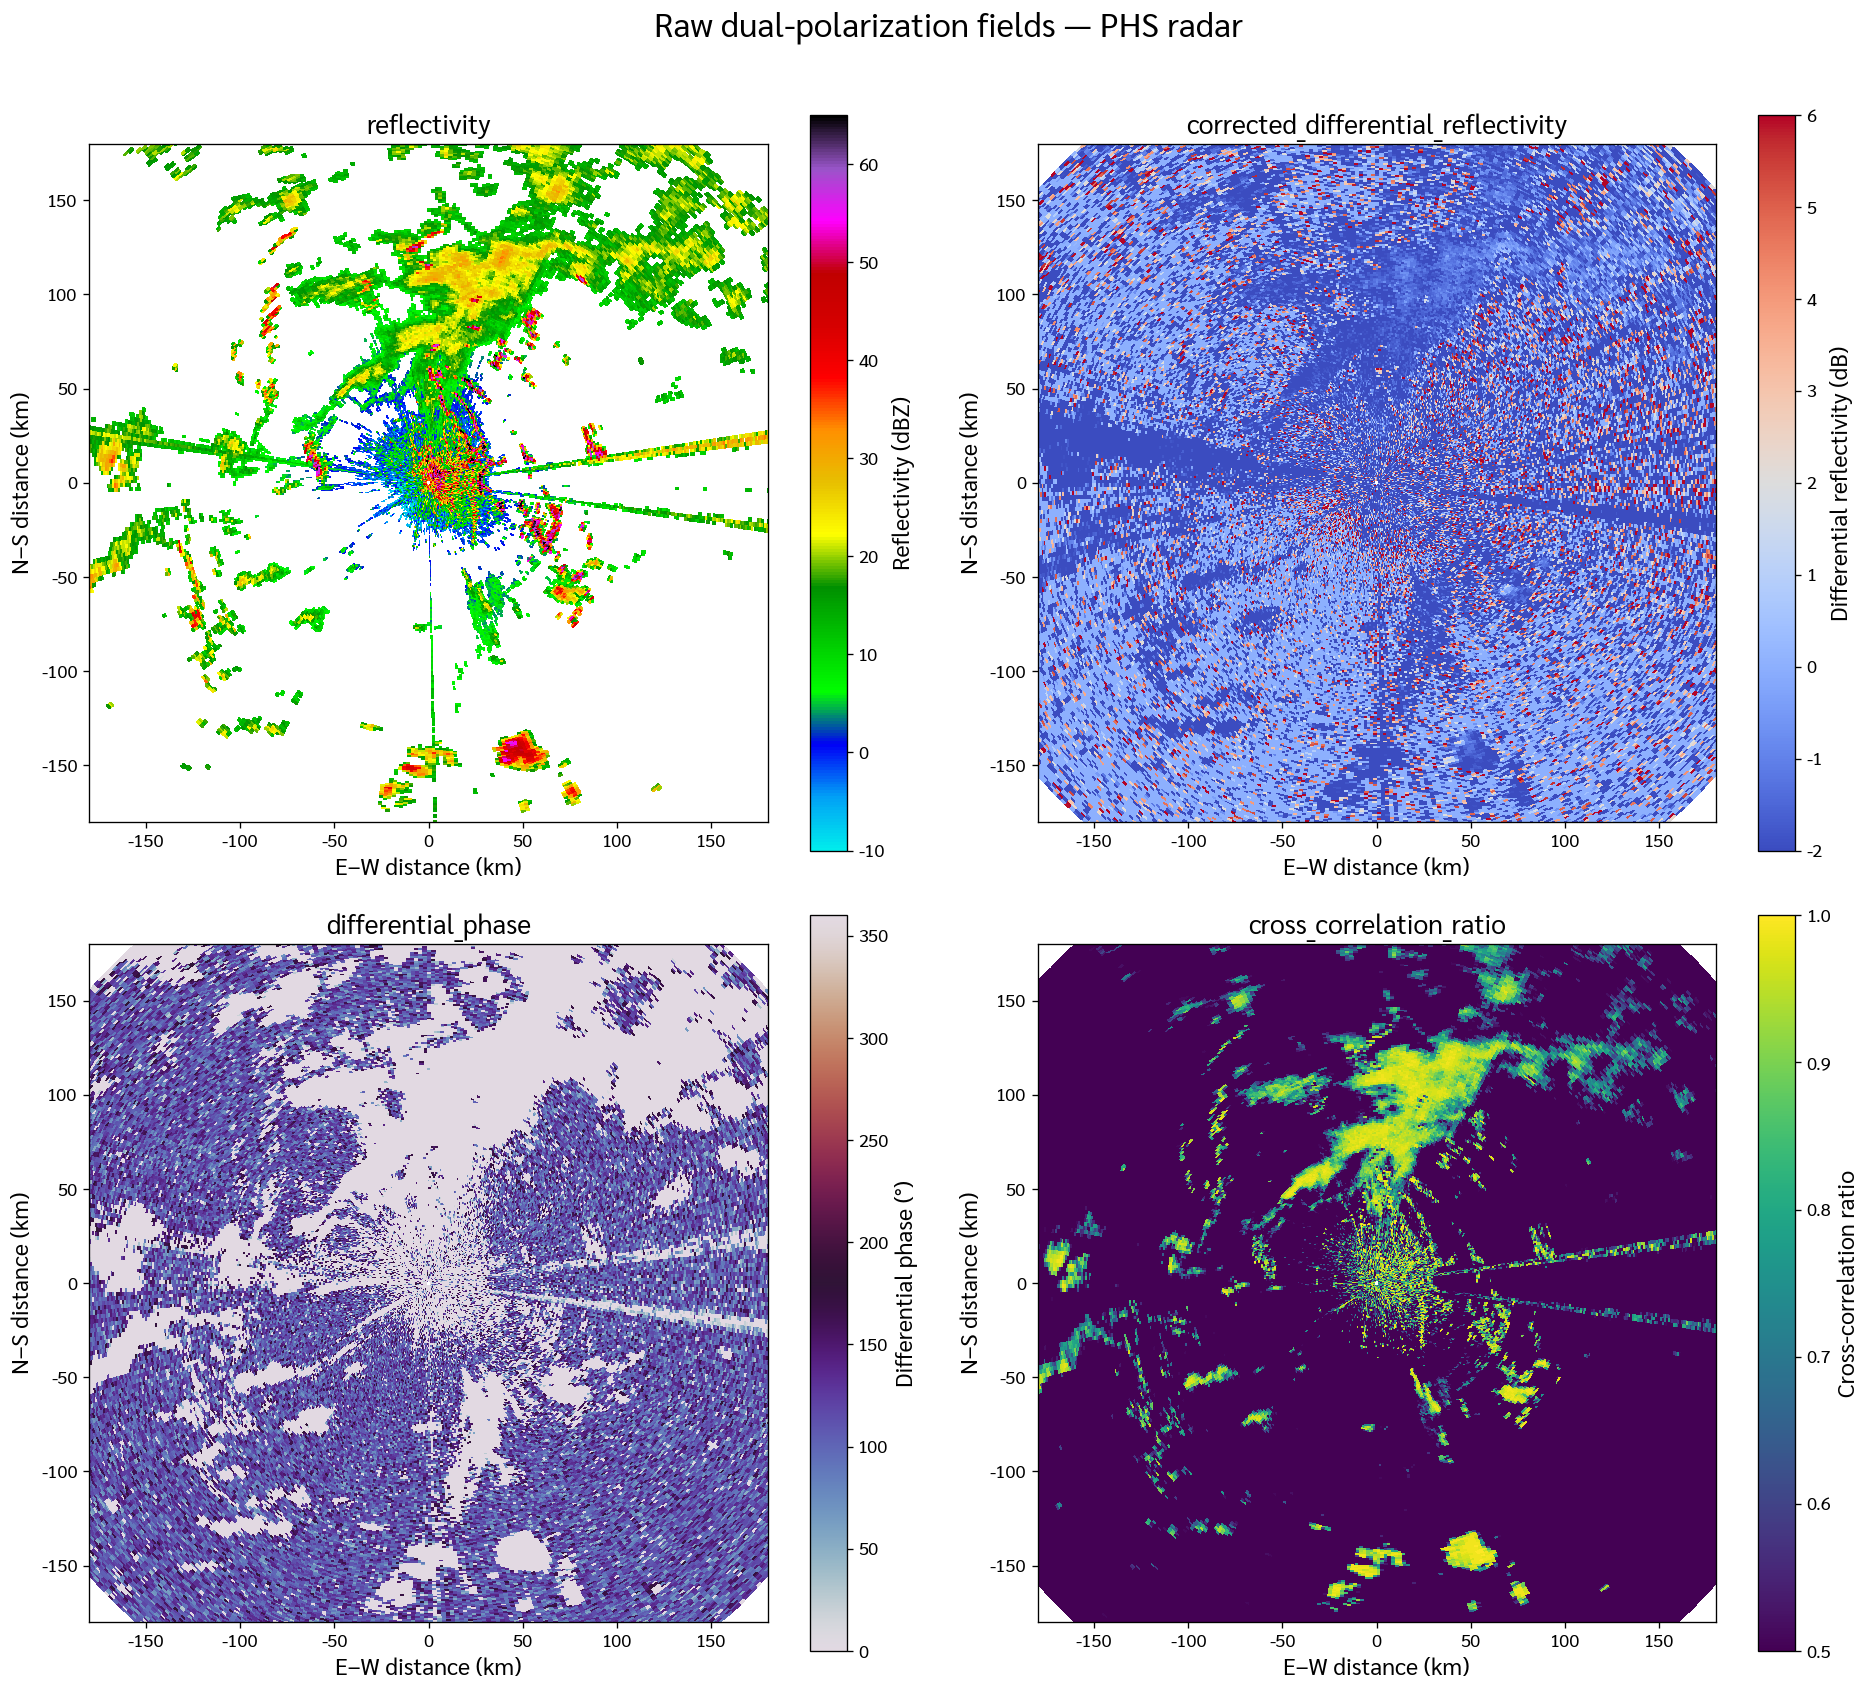

Saved: /content/drive/MyDrive/tmd_radar_course/1results/lesson07/figures/raw_dualpol_PPI_panel.png


In [ ]:
#@title พลอต raw dual-pol PPI
SWEEP = 0
MAX_DISPLAY_RANGE_KM = min(
    180.0,
    float(RANGE_KM.max()),
)

def plot_raw_dualpol_panel():
    figure, axes = plt.subplots(
        2,
        2,
        figsize=(16, 14),
    )
    axes = axes.ravel()
    display = pyart.graph.RadarDisplay(radar)

    specifications = [
        (
            REFLECTIVITY,
            -10,
            65,
            REF_CMAP,
            "Reflectivity (dBZ)",
        ),
        (
            ZDR,
            -2,
            6,
            ZDR_CMAP,
            "Differential reflectivity (dB)",
        ),
        (
            PHIDP_RAW,
            0,
            360,
            PHASE_CMAP,
            "Differential phase (°)",
        ),
        (
            RHOHV,
            0.5,
            1.0,
            RHOHV_CMAP,
            "Cross-correlation ratio",
        ),
    ]

    for axis, (
        field_name,
        vmin,
        vmax,
        cmap,
        colorbar_label,
    ) in zip(axes, specifications):
        display.plot_ppi(
            field_name,
            sweep=SWEEP,
            ax=axis,
            vmin=vmin,
            vmax=vmax,
            cmap=cmap,
            colorbar_label=colorbar_label,
            title=field_name,
        )
        axis.set_xlim(
            -MAX_DISPLAY_RANGE_KM,
            MAX_DISPLAY_RANGE_KM,
        )
        axis.set_ylim(
            -MAX_DISPLAY_RANGE_KM,
            MAX_DISPLAY_RANGE_KM,
        )
        axis.set_aspect("equal")
        axis.set_xlabel("E–W distance (km)")
        axis.set_ylabel("N–S distance (km)")

    figure.suptitle(
        "Raw dual-polarization fields — PHS radar",
        fontsize=20,
        y=1.01,
    )
    figure.tight_layout()

    output = (
        FIGURE_DIR
        / "raw_dualpol_PPI_panel.png"
    )
    figure.savefig(
        output,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    print("Saved:", output)

plot_raw_dualpol_panel()


## 🧹 7. สร้าง Polarimetric QC mask

ค่าเริ่มต้นสำหรับการสาธิต:

\[
Z_H \geq 10\ \text{dBZ}
\]

\[
\rho_{HV} \geq 0.85
\]

\[
-5 \leq Z_{DR} \leq 8\ \text{dB}
\]

และต้องเป็นค่าที่ finite และไม่ถูก mask เดิม

หลังประมวลผล PHIDP จะเพิ่มเงื่อนไข

\[
SD(\Phi_{DP}) \leq 20^\circ
\]

ค่าเหล่านี้ไม่ใช่เกณฑ์สากล ต้องทดลอง sensitivity และตรวจภาพทุกครั้ง

> **เชื่อมกับบทที่ 03:** บทนั้นสอน `GateFilter` แบบทั่วไปสำหรับ reflectivity/velocity ส่วน mask ในบทนี้ทำใหม่โดยเฉพาะสำหรับงาน polarimetric (รวม \(Z_{DR}\), \(\rho_{HV}\) และ \(SD(\Phi_{DP})\)) จึงไม่ใช่การสอนซ้ำ แต่ต่อยอดแนวคิดเดิมให้ละเอียดขึ้นสำหรับ KDP/attenuation/HID


In [ ]:
#@title สร้าง base polarimetric QC mask
QC_MIN_REFLECTIVITY_DBZ = 10.0
QC_MIN_RHOHV = 0.85
QC_MIN_ZDR_DB = -5.0
QC_MAX_ZDR_DB = 8.0
QC_MAX_PHIDP_STD_DEG = 20.0
PHIDP_STD_WINDOW_GATES = 5
PHIDP_SMOOTH_WINDOW_GATES = 9
KDP_DERIVATIVE_WINDOW_GATES = 9
KDP_VALID_MIN = -3.0
KDP_VALID_MAX = 10.0


def field_values_and_mask(
    radar_object,
    field_name: str,
):
    data = np.ma.asarray(
        radar_object.fields[field_name]["data"]
    )
    values = data.filled(np.nan)
    mask = (
        np.ma.getmaskarray(data)
        | ~np.isfinite(values)
    )
    return values.astype(float), mask

ZH_VALUES, ZH_BAD = field_values_and_mask(
    radar,
    REFLECTIVITY,
)
ZDR_VALUES, ZDR_BAD = field_values_and_mask(
    radar,
    ZDR,
)
PHIDP_VALUES, PHIDP_BAD = field_values_and_mask(
    radar,
    PHIDP_RAW,
)
RHOHV_VALUES, RHOHV_BAD = field_values_and_mask(
    radar,
    RHOHV,
)

BASE_QC_MASK = (
    ZH_BAD
    | ZDR_BAD
    | PHIDP_BAD
    | RHOHV_BAD
    | (ZH_VALUES < QC_MIN_REFLECTIVITY_DBZ)
    | (RHOHV_VALUES < QC_MIN_RHOHV)
    | (ZDR_VALUES < QC_MIN_ZDR_DB)
    | (ZDR_VALUES > QC_MAX_ZDR_DB)
)

qc_reason_masks = {
    "invalid_or_masked_reflectivity": ZH_BAD,
    "invalid_or_masked_zdr": ZDR_BAD,
    "invalid_or_masked_phidp": PHIDP_BAD,
    "invalid_or_masked_rhohv": RHOHV_BAD,
    "reflectivity_below_threshold": (
        np.isfinite(ZH_VALUES)
        & (
            ZH_VALUES
            < QC_MIN_REFLECTIVITY_DBZ
        )
    ),
    "rhohv_below_threshold": (
        np.isfinite(RHOHV_VALUES)
        & (
            RHOHV_VALUES
            < QC_MIN_RHOHV
        )
    ),
    "zdr_outside_range": (
        np.isfinite(ZDR_VALUES)
        & (
            (ZDR_VALUES < QC_MIN_ZDR_DB)
            | (ZDR_VALUES > QC_MAX_ZDR_DB)
        )
    ),
}

qc_reason_df = pd.DataFrame([
    {
        "reason": reason,
        "gates": int(mask.sum()),
        "fraction_pct": float(
            100 * mask.mean()
        ),
    }
    for reason, mask in qc_reason_masks.items()
])

display(qc_reason_df.round(3))
print(
    "Base QC excluded:",
    f"{100 * BASE_QC_MASK.mean():.2f}%",
)

qc_reason_df.to_csv(
    CSV_DIR / "base_qc_reasons.csv",
    index=False,
    encoding="utf-8-sig",
)

,reason,gates,fraction_pct
0,invalid_or_masked_reflectivity,348487,75.469
1,invalid_or_masked_zdr,5772,1.250
2,invalid_or_masked_phidp,5772,1.250
3,invalid_or_masked_rhohv,0,0.000
4,reflectivity_below_threshold,33024,7.152
5,rhohv_below_threshold,425475,92.142
6,zdr_outside_range,63478,13.747


Base QC excluded: 93.32%



## 🌀 8. Unwrap, smooth และตรวจ local variability ของ PHIDP

ประมวลผลแยกตาม contiguous valid segment ของแต่ละ ray เพื่อไม่ให้ smoothing ข้าม missing gates

ขั้นตอน:

1. ตรวจ valid segment
2. unwrap PHIDP ด้วย period 360°
3. Savitzky–Golay smoothing
4. rolling standard deviation
5. คำนวณ local derivative
6. แปลงเป็น

\[
K_{DP}
=
\frac{1}{2}
\frac{d\Phi_{DP}}{dr}
\]

การประมาณนี้เป็น transparent educational method และไม่แทน variational retrieval ในทุกสถานการณ์


In [ ]:
#@title ฟังก์ชันประมวลผล PHIDP ตาม contiguous segments
def contiguous_true_slices(
    boolean_array: np.ndarray,
) -> list[slice]:
    values = np.asarray(
        boolean_array,
        dtype=bool,
    )
    padded = np.concatenate(
        [[False], values, [False]]
    )
    transitions = np.diff(
        padded.astype(np.int8)
    )
    starts = np.where(
        transitions == 1
    )[0]
    ends = np.where(
        transitions == -1
    )[0]
    return [
        slice(start, end)
        for start, end in zip(starts, ends)
    ]

def odd_window_not_larger_than(
    requested: int,
    segment_length: int,
    minimum: int = 3,
) -> int | None:
    window = min(
        requested,
        segment_length,
    )
    if window % 2 == 0:
        window -= 1
    if window < minimum:
        return None
    return window

def rolling_std_1d(
    values: np.ndarray,
    window: int,
) -> np.ndarray:
    return (
        pd.Series(values)
        .rolling(
            window=window,
            center=True,
            min_periods=max(
                2,
                window // 2,
            ),
        )
        .std()
        .to_numpy()
    )

def process_phidp_volume(
    raw_phidp: np.ndarray,
    base_qc_mask: np.ndarray,
    *,
    gate_spacing_km: float,
    smooth_window: int = 9,
    derivative_window: int = 9,
    std_window: int = 5,
):
    shape = raw_phidp.shape

    unwrapped = np.full(
        shape,
        np.nan,
        dtype=np.float32,
    )
    filtered = np.full(
        shape,
        np.nan,
        dtype=np.float32,
    )
    local_std = np.full(
        shape,
        np.nan,
        dtype=np.float32,
    )
    kdp = np.full(
        shape,
        np.nan,
        dtype=np.float32,
    )

    valid_gate_counter = 0
    segment_counter = 0

    for ray_index in range(shape[0]):
        valid_ray = (
            ~base_qc_mask[ray_index]
            & np.isfinite(
                raw_phidp[ray_index]
            )
        )

        for segment_slice in contiguous_true_slices(
            valid_ray
        ):
            segment = np.asarray(
                raw_phidp[
                    ray_index,
                    segment_slice,
                ],
                dtype=float,
            )

            if segment.size < 3:
                continue

            segment_counter += 1
            valid_gate_counter += segment.size

            segment_unwrapped = np.unwrap(
                segment,
                period=360.0,
            )

            smooth_length = odd_window_not_larger_than(
                smooth_window,
                segment.size,
                minimum=5,
            )

            if smooth_length is not None:
                segment_filtered = savgol_filter(
                    segment_unwrapped,
                    window_length=smooth_length,
                    polyorder=min(
                        2,
                        smooth_length - 1,
                    ),
                    mode="interp",
                )
            else:
                segment_filtered = segment_unwrapped.copy()

            std_length = odd_window_not_larger_than(
                std_window,
                segment.size,
                minimum=3,
            )
            if std_length is not None:
                segment_std = rolling_std_1d(
                    segment_filtered,
                    std_length,
                )
            else:
                segment_std = np.full(
                    segment.size,
                    np.nan,
                )

            derivative_length = (
                odd_window_not_larger_than(
                    derivative_window,
                    segment.size,
                    minimum=5,
                )
            )

            if derivative_length is not None:
                derivative = savgol_filter(
                    segment_filtered,
                    window_length=derivative_length,
                    polyorder=min(
                        2,
                        derivative_length - 1,
                    ),
                    deriv=1,
                    delta=gate_spacing_km,
                    mode="interp",
                )
            else:
                derivative = np.gradient(
                    segment_filtered,
                    gate_spacing_km,
                )

            segment_kdp = 0.5 * derivative

            unwrapped[
                ray_index,
                segment_slice,
            ] = segment_unwrapped
            filtered[
                ray_index,
                segment_slice,
            ] = segment_filtered
            local_std[
                ray_index,
                segment_slice,
            ] = segment_std
            kdp[
                ray_index,
                segment_slice,
            ] = segment_kdp

    diagnostics = {
        "segments_processed": segment_counter,
        "gates_processed": valid_gate_counter,
    }

    return (
        unwrapped,
        filtered,
        local_std,
        kdp,
        diagnostics,
    )

(
    PHIDP_UNWRAPPED_VALUES,
    PHIDP_FILTERED_VALUES,
    PHIDP_STD_VALUES,
    KDP_LOCAL_VALUES,
    PHASE_DIAGNOSTICS,
) = process_phidp_volume(
    PHIDP_VALUES,
    BASE_QC_MASK,
    gate_spacing_km=GATE_SPACING_KM,
    smooth_window=PHIDP_SMOOTH_WINDOW_GATES,
    derivative_window=KDP_DERIVATIVE_WINDOW_GATES,
    std_window=PHIDP_STD_WINDOW_GATES,
)

print("PHIDP processing:", PHASE_DIAGNOSTICS)
print(
    "Filtered finite gates:",
    int(
        np.isfinite(
            PHIDP_FILTERED_VALUES
        ).sum()
    ),
)

PHIDP processing: {'segments_processed': 2044, 'gates_processed': 23059}
Filtered finite gates: 23059


In [ ]:
#@title สร้าง final phase QC mask และเพิ่มฟิลด์ลง Radar object
PHASE_QC_MASK = (
    BASE_QC_MASK
    | ~np.isfinite(
        PHIDP_FILTERED_VALUES
    )
    | ~np.isfinite(
        PHIDP_STD_VALUES
    )
    | (
        PHIDP_STD_VALUES
        > QC_MAX_PHIDP_STD_DEG
    )
)

KDP_QC_MASK = (
    PHASE_QC_MASK
    | ~np.isfinite(
        KDP_LOCAL_VALUES
    )
    | (
        KDP_LOCAL_VALUES
        < KDP_VALID_MIN
    )
    | (
        KDP_LOCAL_VALUES
        > KDP_VALID_MAX
    )
)

def radar_field(
    data,
    *,
    units: str,
    long_name: str,
    standard_name: str,
    mask=None,
    fill_value: float = -9999.0,
):
    array = np.ma.asarray(
        data,
        dtype=np.float32,
    )

    if mask is not None:
        array = np.ma.array(
            array,
            mask=(
                np.ma.getmaskarray(array)
                | np.asarray(
                    mask,
                    dtype=bool,
                )
            ),
        )

    array.set_fill_value(
        fill_value
    )

    return {
        "data": array,
        "units": units,
        "long_name": long_name,
        "standard_name": standard_name,
        "_FillValue": fill_value,
    }

radar.add_field(
    "phidp_unwrapped",
    radar_field(
        PHIDP_UNWRAPPED_VALUES,
        units="degrees",
        long_name="unwrapped differential phase",
        standard_name="unwrapped_differential_phase",
        mask=BASE_QC_MASK,
    ),
    replace_existing=True,
)

radar.add_field(
    "phidp_filtered",
    radar_field(
        PHIDP_FILTERED_VALUES,
        units="degrees",
        long_name="quality controlled filtered differential phase",
        standard_name="filtered_differential_phase",
        mask=PHASE_QC_MASK,
    ),
    replace_existing=True,
)

radar.add_field(
    "phidp_local_std",
    radar_field(
        PHIDP_STD_VALUES,
        units="degrees",
        long_name="local standard deviation of filtered differential phase",
        standard_name="differential_phase_local_standard_deviation",
        mask=BASE_QC_MASK,
    ),
    replace_existing=True,
)

radar.add_field(
    "kdp_local",
    radar_field(
        KDP_LOCAL_VALUES,
        units="degrees/km",
        long_name="specific differential phase from local Savitzky-Golay derivative",
        standard_name="specific_differential_phase",
        mask=KDP_QC_MASK,
    ),
    replace_existing=True,
)

qc_summary_df = pd.DataFrame([{
    "total_gates": int(
        BASE_QC_MASK.size
    ),
    "base_qc_excluded_pct": float(
        100 * BASE_QC_MASK.mean()
    ),
    "phase_qc_excluded_pct": float(
        100 * PHASE_QC_MASK.mean()
    ),
    "kdp_qc_excluded_pct": float(
        100 * KDP_QC_MASK.mean()
    ),
    "phidp_std_threshold_deg": (
        QC_MAX_PHIDP_STD_DEG
    ),
    "kdp_min_deg_per_km": (
        KDP_VALID_MIN
    ),
    "kdp_max_deg_per_km": (
        KDP_VALID_MAX
    ),
}])

display(qc_summary_df.round(3))
qc_summary_df.to_csv(
    CSV_DIR / "polarimetric_qc_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

,total_gates,base_qc_excluded_pct,phase_qc_excluded_pct,kdp_qc_excluded_pct,phidp_std_threshold_deg,kdp_min_deg_per_km,kdp_max_deg_per_km
0,461760,93.323,95.139,95.19,20.0,-3.0,10.0



## 📈 9. Ray diagnostic: PHIDP และ KDP ตามระยะ

เลือก ray ใน sweep ต่ำสุดที่มี cumulative positive phase change สูง เพื่อให้เห็นผลของ

- raw PHIDP
- unwrapped PHIDP
- filtered PHIDP
- local standard deviation
- local KDP
- reflectivity และ RHOHV ประกอบ


In [ ]:
#@title เลือก representative ray
sweep_slice = radar.get_slice(SWEEP)
sweep_start = int(
    radar.sweep_start_ray_index["data"][SWEEP]
)

phase_change_scores = []

for local_ray_index, global_ray_index in enumerate(
    range(
        sweep_slice.start,
        sweep_slice.stop,
    )
):
    filtered_ray = PHIDP_FILTERED_VALUES[
        global_ray_index
    ]
    finite = np.isfinite(
        filtered_ray
    )

    if finite.sum() >= 5:
        values = filtered_ray[finite]
        score = float(
            np.nanmax(values)
            - np.nanmin(values)
        )
    else:
        score = -np.inf

    phase_change_scores.append(score)

REPRESENTATIVE_LOCAL_RAY = int(
    np.nanargmax(
        phase_change_scores
    )
)
REPRESENTATIVE_GLOBAL_RAY = (
    sweep_start
    + REPRESENTATIVE_LOCAL_RAY
)
REPRESENTATIVE_AZIMUTH = float(
    radar.azimuth["data"][
        REPRESENTATIVE_GLOBAL_RAY
    ]
)

print(
    "Representative ray:",
    REPRESENTATIVE_GLOBAL_RAY,
)
print(
    "Azimuth:",
    f"{REPRESENTATIVE_AZIMUTH:.2f}°",
)
print(
    "Phase-change score:",
    f"{phase_change_scores[REPRESENTATIVE_LOCAL_RAY]:.2f}°",
)

Representative ray: 21
Azimuth: 41.11°
Phase-change score: 470.11°


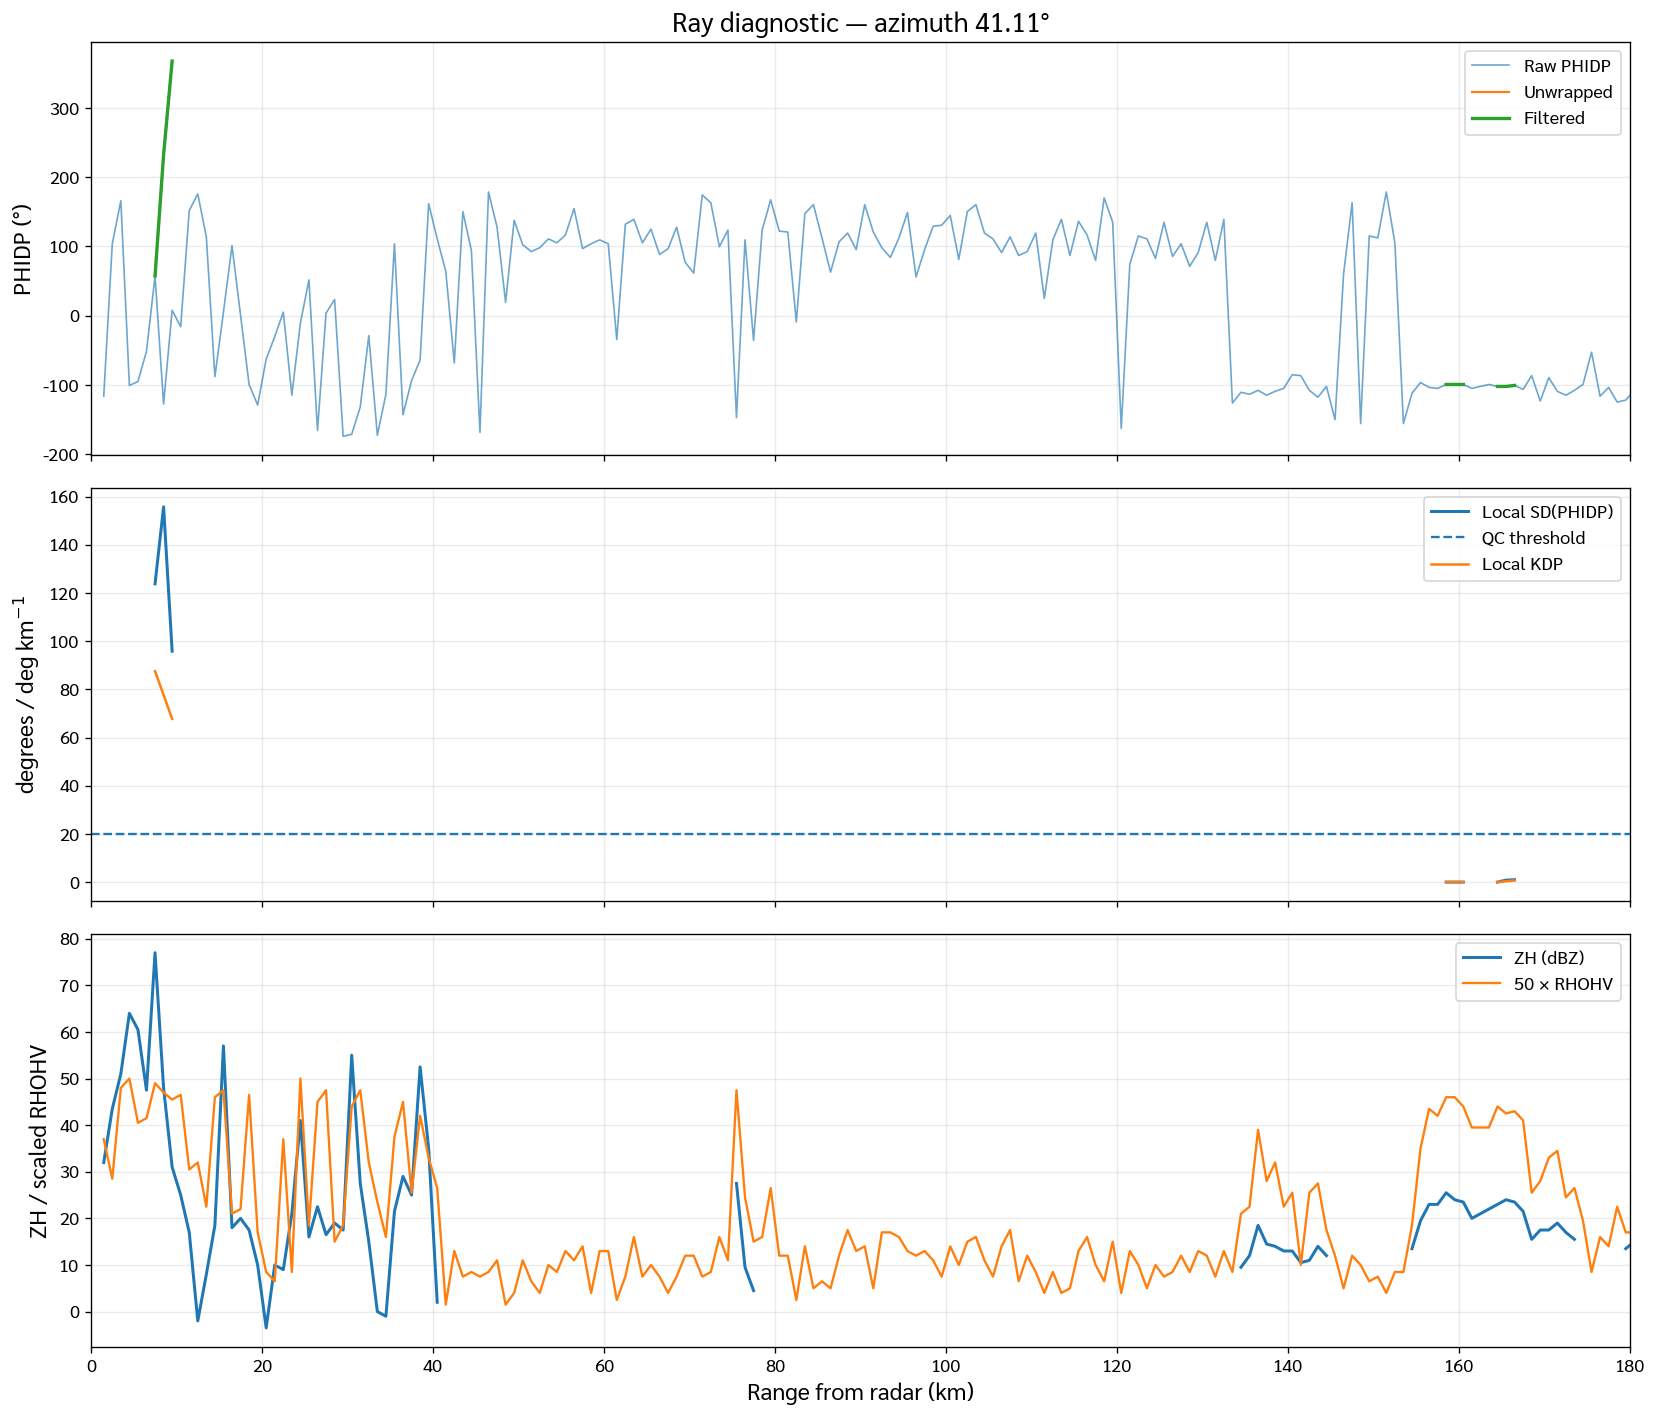

Saved: /content/drive/MyDrive/tmd_radar_course/1results/lesson07/figures/representative_ray_PHIDP_KDP_diagnostics.png


In [ ]:
#@title พลอต representative ray diagnostics
ray = REPRESENTATIVE_GLOBAL_RAY

figure, axes = plt.subplots(
    3,
    1,
    figsize=(14, 12),
    sharex=True,
)

axes[0].plot(
    RANGE_KM,
    PHIDP_VALUES[ray],
    linewidth=1.0,
    alpha=0.65,
    label="Raw PHIDP",
)
axes[0].plot(
    RANGE_KM,
    PHIDP_UNWRAPPED_VALUES[ray],
    linewidth=1.3,
    label="Unwrapped",
)
axes[0].plot(
    RANGE_KM,
    PHIDP_FILTERED_VALUES[ray],
    linewidth=2.0,
    label="Filtered",
)
axes[0].set_ylabel("PHIDP (°)")
axes[0].set_title(
    f"Ray diagnostic — azimuth "
    f"{REPRESENTATIVE_AZIMUTH:.2f}°"
)
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(
    RANGE_KM,
    PHIDP_STD_VALUES[ray],
    linewidth=1.8,
    label="Local SD(PHIDP)",
)
axes[1].axhline(
    QC_MAX_PHIDP_STD_DEG,
    linestyle="--",
    linewidth=1.4,
    label="QC threshold",
)
axes[1].plot(
    RANGE_KM,
    KDP_LOCAL_VALUES[ray],
    linewidth=1.5,
    label="Local KDP",
)
axes[1].set_ylabel("degrees / deg km$^{-1}$")
axes[1].grid(alpha=0.25)
axes[1].legend()

axes[2].plot(
    RANGE_KM,
    ZH_VALUES[ray],
    linewidth=1.8,
    label="ZH (dBZ)",
)
axes[2].plot(
    RANGE_KM,
    50 * RHOHV_VALUES[ray],
    linewidth=1.4,
    label="50 × RHOHV",
)
axes[2].set_xlabel("Range from radar (km)")
axes[2].set_ylabel("ZH / scaled RHOHV")
axes[2].grid(alpha=0.25)
axes[2].legend()

axes[2].set_xlim(
    0,
    min(
        180,
        RANGE_KM.max(),
    ),
)

figure.tight_layout()

ray_figure = (
    FIGURE_DIR
    / "representative_ray_PHIDP_KDP_diagnostics.png"
)
figure.savefig(
    ray_figure,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

ray_export = pd.DataFrame({
    "range_km": RANGE_KM,
    "reflectivity_dbz": ZH_VALUES[ray],
    "zdr_db": ZDR_VALUES[ray],
    "rhohv": RHOHV_VALUES[ray],
    "phidp_raw_deg": PHIDP_VALUES[ray],
    "phidp_unwrapped_deg": (
        PHIDP_UNWRAPPED_VALUES[ray]
    ),
    "phidp_filtered_deg": (
        PHIDP_FILTERED_VALUES[ray]
    ),
    "phidp_local_std_deg": (
        PHIDP_STD_VALUES[ray]
    ),
    "kdp_local_deg_per_km": (
        KDP_LOCAL_VALUES[ray]
    ),
})
ray_export.to_csv(
    CSV_DIR / "representative_ray_diagnostics.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Saved:", ray_figure)


## 🗺️ 10. PPI ของ PHIDP และ KDP หลัง QC


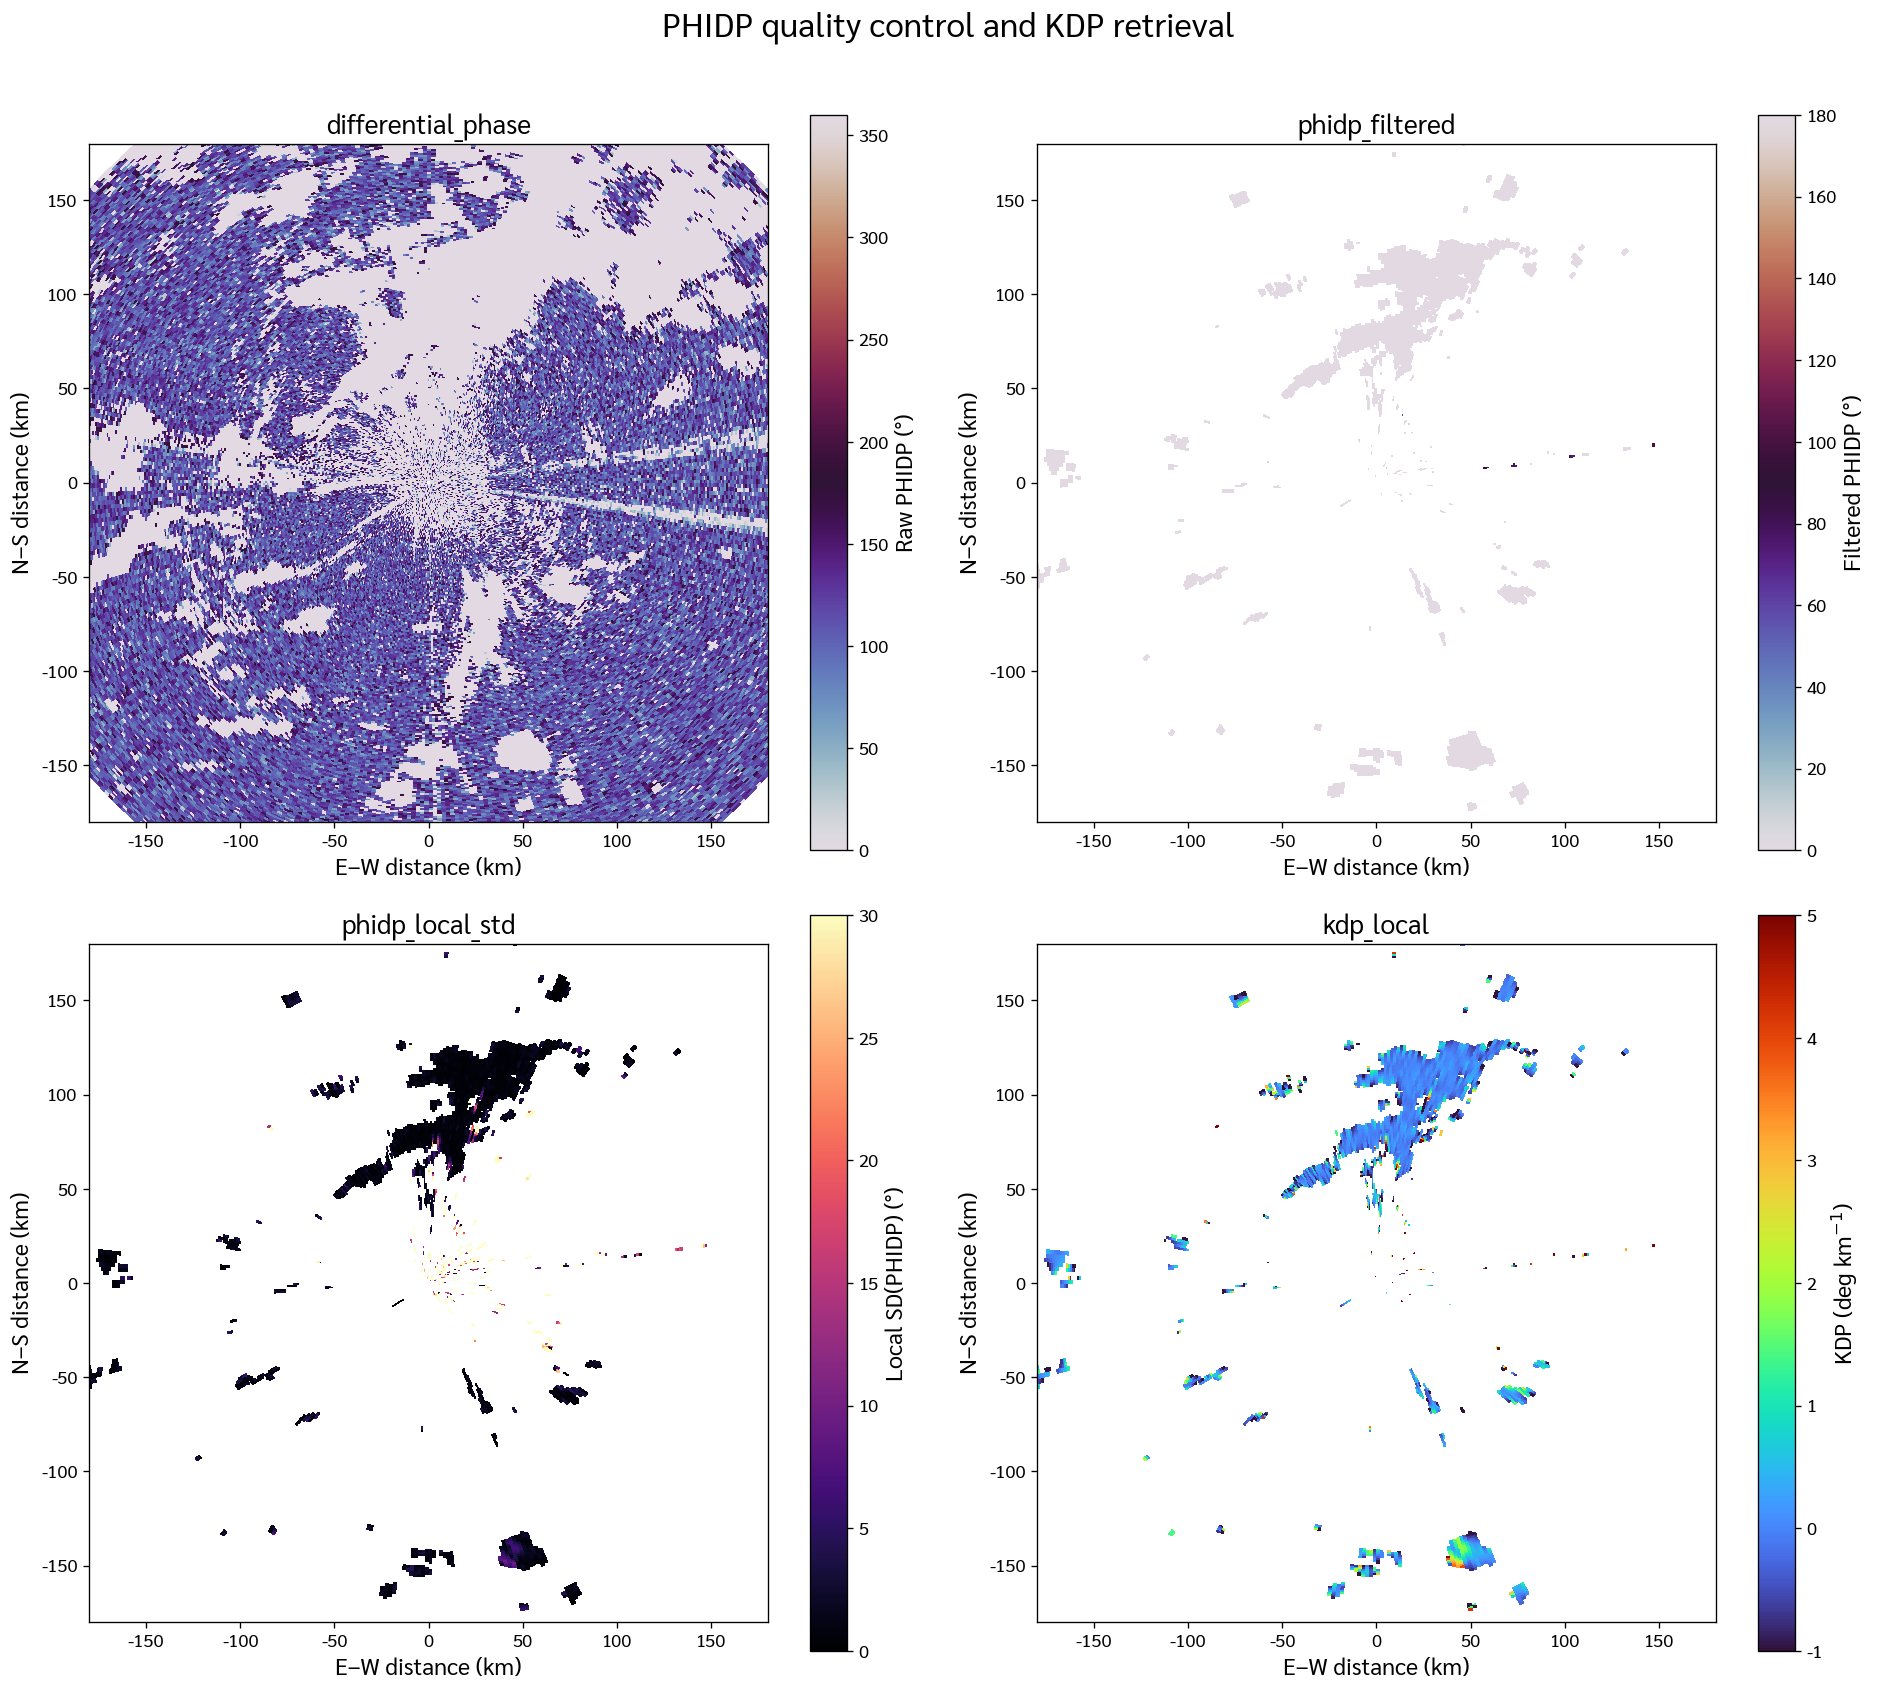

Saved: /content/drive/MyDrive/tmd_radar_course/1results/lesson07/figures/PHIDP_QC_and_KDP_PPI.png


In [ ]:
#@title พลอต processed phase PPI
figure, axes = plt.subplots(
    2,
    2,
    figsize=(16, 14),
)
axes = axes.ravel()

radar_display = pyart.graph.RadarDisplay(
    radar
)

specifications = [
    (
        PHIDP_RAW,
        0,
        360,
        PHASE_CMAP,
        "Raw PHIDP (°)",
    ),
    (
        "phidp_filtered",
        0,
        180,
        PHASE_CMAP,
        "Filtered PHIDP (°)",
    ),
    (
        "phidp_local_std",
        0,
        30,
        "magma",
        "Local SD(PHIDP) (°)",
    ),
    (
        "kdp_local",
        -1,
        5,
        KDP_CMAP,
        "KDP (deg km$^{-1}$)",
    ),
]

for axis, (
    field_name,
    vmin,
    vmax,
    cmap,
    colorbar_label,
) in zip(axes, specifications):
    radar_display.plot_ppi(
        field_name,
        sweep=SWEEP,
        ax=axis,
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
        colorbar_label=colorbar_label,
        title=field_name,
    )
    axis.set_xlim(
        -MAX_DISPLAY_RANGE_KM,
        MAX_DISPLAY_RANGE_KM,
    )
    axis.set_ylim(
        -MAX_DISPLAY_RANGE_KM,
        MAX_DISPLAY_RANGE_KM,
    )
    axis.set_aspect("equal")
    axis.set_xlabel("E–W distance (km)")
    axis.set_ylabel("N–S distance (km)")

figure.suptitle(
    "PHIDP quality control and KDP retrieval",
    fontsize=20,
    y=1.01,
)
figure.tight_layout()

phase_ppi = (
    FIGURE_DIR
    / "PHIDP_QC_and_KDP_PPI.png"
)
figure.savefig(
    phase_ppi,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print("Saved:", phase_ppi)


## 🧮 11. เปรียบเทียบกับ hardware KDP ถ้ามี

หาก UF มี KDP จาก signal processor จะเปรียบเทียบกับ `kdp_local` โดยรายงาน

- common valid gates
- correlation
- mean difference
- MAE
- RMSE

ความแตกต่างไม่ได้แปลว่าวิธีหนึ่งผิดทันที เพราะอัลกอริทึม filtering, window length, clipping และ calibration อาจต่างกัน


In [ ]:
#@title เปรียบเทียบ local KDP กับ hardware KDP
kdp_comparison_status = {
    "hardware_kdp_available": (
        HARDWARE_KDP is not None
    ),
}

if HARDWARE_KDP is None:
    print(
        "ไม่พบ hardware KDP ในไฟล์ — "
        "ใช้ kdp_local เป็นหลัก"
    )
    kdp_comparison_df = pd.DataFrame([
        kdp_comparison_status
    ])

else:
    hardware_values, hardware_bad = (
        field_values_and_mask(
            radar,
            HARDWARE_KDP,
        )
    )

    common_valid = (
        ~KDP_QC_MASK
        & ~hardware_bad
        & np.isfinite(
            hardware_values
        )
        & np.isfinite(
            KDP_LOCAL_VALUES
        )
    )

    local = KDP_LOCAL_VALUES[
        common_valid
    ]
    hardware = hardware_values[
        common_valid
    ]

    if local.size:
        difference = local - hardware
        correlation = (
            float(
                np.corrcoef(
                    local,
                    hardware,
                )[0, 1]
            )
            if local.size > 2
            else np.nan
        )

        kdp_comparison_status.update({
            "common_valid_gates": int(
                local.size
            ),
            "correlation": correlation,
            "mean_local_minus_hardware": float(
                np.nanmean(difference)
            ),
            "mae_deg_per_km": float(
                np.nanmean(
                    np.abs(difference)
                )
            ),
            "rmse_deg_per_km": float(
                np.sqrt(
                    np.nanmean(
                        difference ** 2
                    )
                )
            ),
        })

        sample_size = min(
            50_000,
            local.size,
        )
        sample_indices = np.linspace(
            0,
            local.size - 1,
            sample_size,
            dtype=int,
        )

        figure, axis = plt.subplots(
            figsize=(7.5, 7)
        )
        axis.scatter(
            hardware[sample_indices],
            local[sample_indices],
            s=5,
            alpha=0.25,
        )
        limits = [-2, 6]
        axis.plot(
            limits,
            limits,
            linestyle="--",
        )
        axis.set_xlim(*limits)
        axis.set_ylim(*limits)
        axis.set_aspect("equal")
        axis.set_xlabel(
            f"{HARDWARE_KDP} (deg km$^{{-1}}$)"
        )
        axis.set_ylabel(
            "kdp_local (deg km$^{-1}$)"
        )
        axis.set_title(
            "Local KDP versus hardware KDP"
        )
        axis.grid(alpha=0.25)
        figure.tight_layout()

        kdp_scatter = (
            FIGURE_DIR
            / "local_vs_hardware_KDP.png"
        )
        figure.savefig(
            kdp_scatter,
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()

    kdp_comparison_df = pd.DataFrame([
        kdp_comparison_status
    ])

display(kdp_comparison_df.round(4))
kdp_comparison_df.to_csv(
    CSV_DIR / "kdp_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)

ไม่พบ hardware KDP ในไฟล์ — ใช้ kdp_local เป็นหลัก


,hardware_kdp_available
0,False



## 🧪 12. ทางเลือก: Maesaka variational KDP

Py-ART มี `kdp_maesaka` ซึ่งสมมติว่า propagation PHIDP เพิ่มขึ้นตามระยะและเหมาะโดยหลักกับ rain below melting layer หรือ warm cloud

เนื่องจาก optimization อาจใช้เวลามากใน Colab จึงปิดเป็นค่าเริ่มต้น

```python
RUN_MAESAKA = False
```

เปลี่ยนเป็น `True` เพื่อทดลอง โดยผลยังต้องตรวจด้วย ray profiles และ PPI


In [ ]:
#@title ทดลอง Maesaka KDP
RUN_MAESAKA = False

maesaka_status = {
    "requested": RUN_MAESAKA,
    "success": False,
    "elapsed_seconds": None,
    "error": None,
}

if RUN_MAESAKA:
    maesaka_gatefilter = pyart.filters.GateFilter(
        radar
    )
    maesaka_gatefilter.exclude_gates(
        PHASE_QC_MASK
    )

    start_time = time.perf_counter()

    try:
        (
            maesaka_kdp,
            maesaka_forward_phidp,
            maesaka_reverse_phidp,
        ) = pyart.retrieve.kdp_maesaka(
            radar,
            gatefilter=maesaka_gatefilter,
            psidp_field="phidp_filtered",
            kdp_field="kdp_maesaka",
            phidp_field="phidp_maesaka",
            method="cg",
            proc=1,
            debug=False,
            verbose=False,
            maxiter=50,
        )

        radar.add_field(
            "kdp_maesaka",
            maesaka_kdp,
            replace_existing=True,
        )
        radar.add_field(
            "phidp_maesaka_forward",
            maesaka_forward_phidp,
            replace_existing=True,
        )
        radar.add_field(
            "phidp_maesaka_reverse",
            maesaka_reverse_phidp,
            replace_existing=True,
        )

        maesaka_status["success"] = True
        maesaka_status["elapsed_seconds"] = (
            time.perf_counter()
            - start_time
        )

        figure, axis = plt.subplots(
            figsize=(9, 8)
        )
        radar_display = pyart.graph.RadarDisplay(
            radar
        )
        radar_display.plot_ppi(
            "kdp_maesaka",
            sweep=SWEEP,
            ax=axis,
            vmin=-1,
            vmax=5,
            cmap=KDP_CMAP,
            colorbar_label=(
                "Maesaka KDP "
                "(deg km$^{-1}$)"
            ),
        )
        axis.set_xlim(
            -MAX_DISPLAY_RANGE_KM,
            MAX_DISPLAY_RANGE_KM,
        )
        axis.set_ylim(
            -MAX_DISPLAY_RANGE_KM,
            MAX_DISPLAY_RANGE_KM,
        )
        axis.set_aspect("equal")
        figure.tight_layout()

        output = (
            FIGURE_DIR
            / "KDP_Maesaka_PPI.png"
        )
        figure.savefig(
            output,
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()

    except Exception as error:
        maesaka_status["elapsed_seconds"] = (
            time.perf_counter()
            - start_time
        )
        maesaka_status["error"] = repr(
            error
        )
        print("Maesaka KDP ไม่สำเร็จ:", error)

else:
    print(
        "ข้าม Maesaka KDP "
        "เพื่อให้ Run all ใช้เวลาสั้นลง"
    )

maesaka_status_df = pd.DataFrame([
    maesaka_status
])
display(maesaka_status_df)
maesaka_status_df.to_csv(
    CSV_DIR / "maesaka_status.csv",
    index=False,
    encoding="utf-8-sig",
)

ข้าม Maesaka KDP เพื่อให้ Run all ใช้เวลาสั้นลง


,requested,success,elapsed_seconds,error
0,False,False,None,None



## 🌡️ 13. อ่าน sounding และหา isotherm heights

Parser ใช้สามคอลัมน์แรกของ University of Wyoming sounding text:

- pressure (hPa)
- height (m MSL)
- temperature (°C)

จากนั้นหา first upward crossing ของ

- 0 °C
- −10 °C
- −20 °C
- −30 °C


In [ ]:
#@title อ่าน sounding temperature profile
def is_number(
    value: str,
) -> bool:
    try:
        float(value)
        return True
    except Exception:
        return False

def parse_wyoming_temperature_profile(
    path: Path,
) -> pd.DataFrame:
    rows = []

    with path.open(
        "r",
        encoding="utf-8",
        errors="ignore",
    ) as file:
        for line in file:
            tokens = line.strip().split()

            if (
                len(tokens) < 3
                or not all(
                    is_number(token)
                    for token in tokens[:3]
                )
            ):
                continue

            pressure = float(tokens[0])
            height = float(tokens[1])
            temperature = float(tokens[2])

            if not (
                50 <= pressure <= 1100
                and -500 <= height <= 40_000
                and -100 <= temperature <= 60
            ):
                continue

            rows.append({
                "pressure_hpa": pressure,
                "height_m_msl": height,
                "temperature_c": temperature,
            })

    if not rows:
        raise ValueError(
            "ไม่สามารถอ่าน sounding profile ได้"
        )

    profile = (
        pd.DataFrame(rows)
        .drop_duplicates(
            subset="height_m_msl",
        )
        .sort_values(
            "height_m_msl",
        )
        .reset_index(drop=True)
    )

    return profile

sounding_profile = parse_wyoming_temperature_profile(
    LOCAL_SOUNDING
)

display(sounding_profile.head())
print(
    "Sounding levels:",
    len(sounding_profile),
)
print(
    "Height range:",
    f"{sounding_profile['height_m_msl'].min():.0f}–"
    f"{sounding_profile['height_m_msl'].max():.0f} m MSL",
)

sounding_profile.to_csv(
    CSV_DIR / "sounding_temperature_profile.csv",
    index=False,
    encoding="utf-8-sig",
)

,pressure_hpa,height_m_msl,temperature_c
0,972.0,314.0,27.4
1,947.0,544.0,27.8
2,925.0,751.0,27.2
3,850.0,1497.0,22.6
4,790.0,2132.0,19.0


Sounding levels: 70
Height range: 314–15164 m MSL


,temperature_c,height_m_msl
0,0.0,5486.8
1,-10.0,6889.1
2,-20.0,8154.0
3,-30.0,9599.6


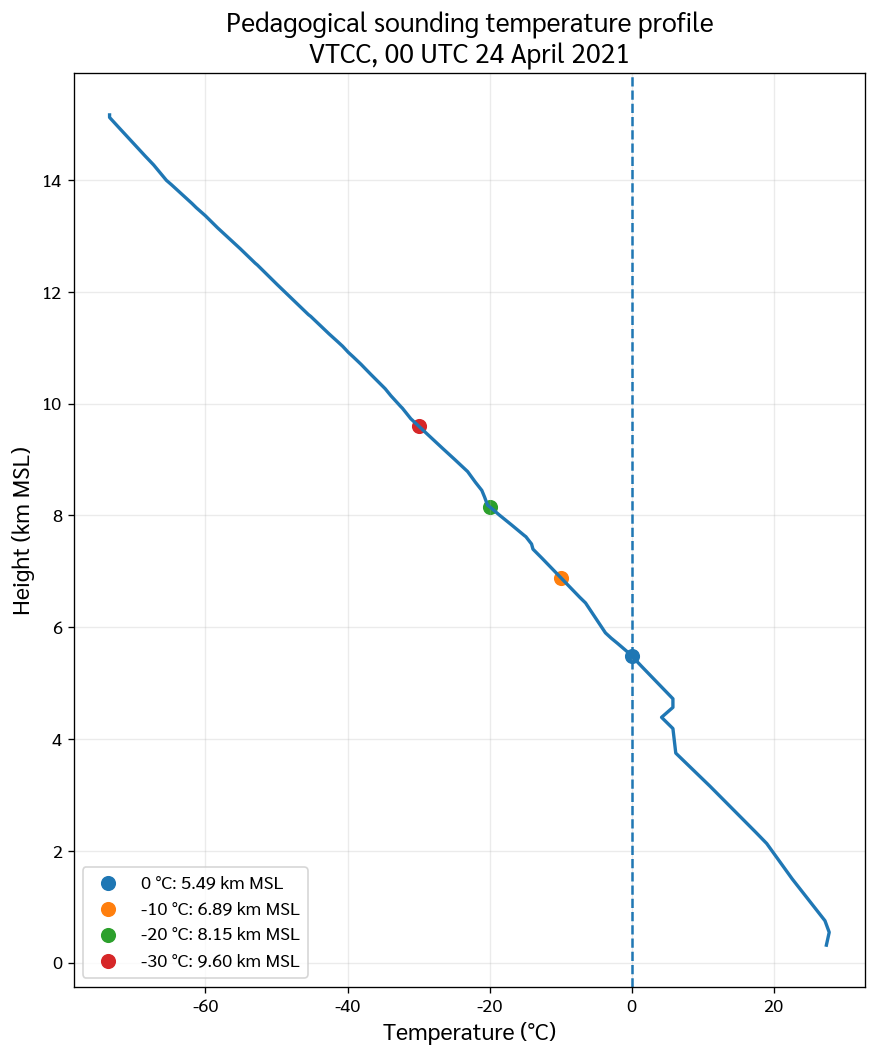

Saved: /content/drive/MyDrive/tmd_radar_course/1results/lesson07/figures/sounding_temperature_and_isotherms.png


In [ ]:
#@title หา isotherm heights
def first_isotherm_crossing_height(
    profile: pd.DataFrame,
    target_temperature_c: float,
) -> float:
    height = profile[
        "height_m_msl"
    ].to_numpy(dtype=float)
    temperature = profile[
        "temperature_c"
    ].to_numpy(dtype=float)

    for index in range(
        len(profile) - 1
    ):
        t0 = temperature[index]
        t1 = temperature[index + 1]

        if not (
            np.isfinite(t0)
            and np.isfinite(t1)
        ):
            continue

        if (
            (t0 - target_temperature_c)
            * (t1 - target_temperature_c)
            <= 0
            and t0 != t1
        ):
            fraction = (
                target_temperature_c - t0
            ) / (t1 - t0)

            return float(
                height[index]
                + fraction
                * (
                    height[index + 1]
                    - height[index]
                )
            )

    return np.nan

ISOTHERM_TARGETS_C = [
    0.0,
    -10.0,
    -20.0,
    -30.0,
]

isotherm_rows = [
    {
        "temperature_c": target,
        "height_m_msl": (
            first_isotherm_crossing_height(
                sounding_profile,
                target,
            )
        ),
    }
    for target in ISOTHERM_TARGETS_C
]

isotherm_df = pd.DataFrame(
    isotherm_rows
)
display(isotherm_df.round(1))

FREEZING_LEVEL_M_MSL = float(
    isotherm_df.loc[
        isotherm_df[
            "temperature_c"
        ] == 0.0,
        "height_m_msl",
    ].iloc[0]
)

isotherm_df.to_csv(
    CSV_DIR / "sounding_isotherm_heights.csv",
    index=False,
    encoding="utf-8-sig",
)

figure, axis = plt.subplots(
    figsize=(7.5, 9)
)
axis.plot(
    sounding_profile["temperature_c"],
    sounding_profile["height_m_msl"] / 1000.0,
    linewidth=2.0,
)
for _, row in isotherm_df.iterrows():
    if np.isfinite(
        row["height_m_msl"]
    ):
        axis.scatter(
            row["temperature_c"],
            row["height_m_msl"] / 1000.0,
            s=65,
            label=(
                f"{row['temperature_c']:.0f} °C: "
                f"{row['height_m_msl'] / 1000:.2f} km MSL"
            ),
        )
axis.axvline(
    0,
    linestyle="--",
)
axis.set_xlabel("Temperature (°C)")
axis.set_ylabel("Height (km MSL)")
axis.set_title(
    "Pedagogical sounding temperature profile\n"
    "VTCC, 00 UTC 24 April 2021"
)
axis.grid(alpha=0.25)
axis.legend()
figure.tight_layout()

sounding_figure = (
    FIGURE_DIR
    / "sounding_temperature_and_isotherms.png"
)
figure.savefig(
    sounding_figure,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print("Saved:", sounding_figure)


## 🌡️ 14. Map temperature ลงบน radar gates

ใช้ `pyart.retrieve.map_profile_to_gates` เพื่อ interpolate temperature profile ไปยังทุก radar gate ตาม gate height

ผลลัพธ์:

- `gate_height_profile`
- `temperature`

Temperature field จะใช้เป็น input ของ HID และ Z–PHI attenuation


In [ ]:
#@title Map sounding profile to radar gates
temperature_profile_c = sounding_profile[
    "temperature_c"
].to_numpy(dtype=float)
height_profile_m_msl = sounding_profile[
    "height_m_msl"
].to_numpy(dtype=float)

(
    gate_height_field,
    gate_temperature_field,
) = pyart.retrieve.map_profile_to_gates(
    temperature_profile_c,
    height_profile_m_msl,
    radar,
    profile_field="temperature",
    height_field="gate_height_profile",
)

radar.add_field(
    "gate_height_profile",
    gate_height_field,
    replace_existing=True,
)
radar.add_field(
    "temperature",
    gate_temperature_field,
    replace_existing=True,
)

temperature_data = np.ma.asarray(
    radar.fields["temperature"]["data"]
)

print(
    "Mapped temperature range:",
    f"{temperature_data.min():.2f} to "
    f"{temperature_data.max():.2f} °C",
)
print(
    "Freezing level from sounding:",
    f"{FREEZING_LEVEL_M_MSL / 1000:.2f} km MSL",
)

Mapped temperature range: -73.48 to 27.80 °C
Freezing level from sounding: 5.49 km MSL



## 🌧️ 15. Z–PHI attenuation correction

ขั้นตอนหลักใช้

```python
pyart.correct.calculate_attenuation_zphi
```

Input:

- reflectivity
- filtered PHIDP
- ZDR
- mapped temperature
- GateFilter

Output:

- specific attenuation
- path-integrated attenuation
- corrected reflectivity
- specific differential attenuation
- path-integrated differential attenuation
- corrected ZDR

หาก Z–PHI ไม่สำเร็จ จะใช้ fallback แบบ PHIDP-linear เพื่อให้บทเรียนดำเนินต่อได้ โดย fallback จะถูกระบุใน metadata ว่าเป็น pedagogical approximation


In [ ]:
#@title เตรียม radar frequency และ attenuation GateFilter
NOMINAL_C_BAND_FREQUENCY_HZ = 5.6e9

if radar.instrument_parameters is None:
    radar.instrument_parameters = {}

if (
    "frequency"
    not in radar.instrument_parameters
):
    radar.instrument_parameters[
        "frequency"
    ] = {
        "long_name": (
            "nominal radar frequency "
            "used for pedagogical retrieval"
        ),
        "units": "Hz",
        "data": np.array(
            [NOMINAL_C_BAND_FREQUENCY_HZ],
            dtype=np.float32,
        ),
    }

attenuation_gatefilter = pyart.filters.GateFilter(
    radar
)
attenuation_gatefilter.exclude_gates(
    PHASE_QC_MASK
)

RADAR_FREQUENCY_HZ = float(
    radar.instrument_parameters[
        "frequency"
    ]["data"][0]
)

print(
    "Radar frequency used (Hz):",
    f"{RADAR_FREQUENCY_HZ:.4e}",
    "(actual, from UF metadata)"
    if RADAR_FREQUENCY_HZ != NOMINAL_C_BAND_FREQUENCY_HZ
    else "(nominal fallback, metadata missing)",
)
print(
    "Attenuation excluded gates:",
    f"{100 * attenuation_gatefilter.gate_excluded.mean():.2f}%",
)

Radar frequency used (Hz): 5.5938e+09 (actual, from UF metadata)
Attenuation excluded gates: 95.14%


In [ ]:
#@title ทำ attenuation correction
ATTENUATION_METHOD = None
ATTENUATION_ERROR = None

SPECIFIC_ATTENUATION_FIELD = (
    "specific_attenuation"
)
PIA_FIELD = (
    "path_integrated_attenuation"
)
CORRECTED_REFLECTIVITY_FIELD = (
    "corrected_reflectivity_zphi"
)
SPECIFIC_DIFFERENTIAL_ATTENUATION_FIELD = (
    "specific_differential_attenuation"
)
PIDA_FIELD = (
    "path_integrated_differential_attenuation"
)
CORRECTED_ZDR_FIELD = (
    "corrected_zdr_zphi"
)

try:
    (
        specific_attenuation,
        pia,
        corrected_reflectivity,
        specific_differential_attenuation,
        pida,
        corrected_zdr,
    ) = pyart.correct.calculate_attenuation_zphi(
        radar,
        doc=10,
        fzl=None,
        smooth_window_len=5,
        gatefilter=attenuation_gatefilter,
        refl_field=REFLECTIVITY,
        phidp_field="phidp_filtered",
        zdr_field=ZDR,
        temp_field="temperature",
        iso0_field=None,
        spec_at_field=SPECIFIC_ATTENUATION_FIELD,
        pia_field=PIA_FIELD,
        corr_refl_field=(
            CORRECTED_REFLECTIVITY_FIELD
        ),
        spec_diff_at_field=(
            SPECIFIC_DIFFERENTIAL_ATTENUATION_FIELD
        ),
        pida_field=PIDA_FIELD,
        corr_zdr_field=CORRECTED_ZDR_FIELD,
        temp_ref="temperature",
    )

    returned_fields = [
        (
            SPECIFIC_ATTENUATION_FIELD,
            specific_attenuation,
        ),
        (
            PIA_FIELD,
            pia,
        ),
        (
            CORRECTED_REFLECTIVITY_FIELD,
            corrected_reflectivity,
        ),
        (
            SPECIFIC_DIFFERENTIAL_ATTENUATION_FIELD,
            specific_differential_attenuation,
        ),
        (
            PIDA_FIELD,
            pida,
        ),
        (
            CORRECTED_ZDR_FIELD,
            corrected_zdr,
        ),
    ]

    for field_name, field_dictionary in returned_fields:
        if field_dictionary is not None:
            radar.add_field(
                field_name,
                field_dictionary,
                replace_existing=True,
            )

    ATTENUATION_METHOD = (
        "Py-ART calculate_attenuation_zphi"
    )

except Exception as error:
    ATTENUATION_ERROR = repr(error)
    ATTENUATION_METHOD = (
        "pedagogical PHIDP-linear fallback"
    )

    print(
        "Z–PHI ไม่สำเร็จ จึงใช้ fallback:",
        error,
    )

    filtered = np.asarray(
        PHIDP_FILTERED_VALUES,
        dtype=float,
    )
    delta_phi = np.full_like(
        filtered,
        np.nan,
        dtype=float,
    )

    for ray_index in range(
        radar.nrays
    ):
        valid = (
            ~PHASE_QC_MASK[ray_index]
            & np.isfinite(
                filtered[ray_index]
            )
        )
        valid_indices = np.where(
            valid
        )[0]

        if valid_indices.size < 2:
            continue

        first_value = filtered[
            ray_index,
            valid_indices[0]
        ]
        ray_delta = (
            filtered[ray_index]
            - first_value
        )
        ray_delta = np.maximum(
            ray_delta,
            0.0,
        )
        delta_phi[ray_index] = (
            ray_delta
        )

    ATTENUATION_ALPHA_DB_PER_DEG = 0.08
    DIFFERENTIAL_ALPHA_DB_PER_DEG = 0.02

    pia_values = (
        ATTENUATION_ALPHA_DB_PER_DEG
        * delta_phi
    )
    pida_values = (
        DIFFERENTIAL_ALPHA_DB_PER_DEG
        * delta_phi
    )

    specific_attenuation_values = (
        0.5
        * np.gradient(
            pia_values,
            GATE_SPACING_KM,
            axis=1,
        )
    )
    specific_differential_values = (
        0.5
        * np.gradient(
            pida_values,
            GATE_SPACING_KM,
            axis=1,
        )
    )

    corrected_reflectivity_values = (
        ZH_VALUES
        + pia_values
    )
    corrected_zdr_values = (
        ZDR_VALUES
        + pida_values
    )

    fallback_fields = [
        (
            SPECIFIC_ATTENUATION_FIELD,
            radar_field(
                specific_attenuation_values,
                units="dB/km",
                long_name=(
                    "pedagogical specific attenuation"
                ),
                standard_name=(
                    "specific_attenuation"
                ),
                mask=PHASE_QC_MASK,
            ),
        ),
        (
            PIA_FIELD,
            radar_field(
                pia_values,
                units="dB",
                long_name=(
                    "pedagogical path integrated attenuation"
                ),
                standard_name=(
                    "path_integrated_attenuation"
                ),
                mask=PHASE_QC_MASK,
            ),
        ),
        (
            CORRECTED_REFLECTIVITY_FIELD,
            radar_field(
                corrected_reflectivity_values,
                units="dBZ",
                long_name=(
                    "reflectivity corrected by pedagogical PHIDP-linear method"
                ),
                standard_name=(
                    "corrected_reflectivity"
                ),
                mask=PHASE_QC_MASK,
            ),
        ),
        (
            SPECIFIC_DIFFERENTIAL_ATTENUATION_FIELD,
            radar_field(
                specific_differential_values,
                units="dB/km",
                long_name=(
                    "pedagogical specific differential attenuation"
                ),
                standard_name=(
                    "specific_differential_attenuation"
                ),
                mask=PHASE_QC_MASK,
            ),
        ),
        (
            PIDA_FIELD,
            radar_field(
                pida_values,
                units="dB",
                long_name=(
                    "pedagogical path integrated differential attenuation"
                ),
                standard_name=(
                    "path_integrated_differential_attenuation"
                ),
                mask=PHASE_QC_MASK,
            ),
        ),
        (
            CORRECTED_ZDR_FIELD,
            radar_field(
                corrected_zdr_values,
                units="dB",
                long_name=(
                    "ZDR corrected by pedagogical PHIDP-linear method"
                ),
                standard_name=(
                    "corrected_differential_reflectivity"
                ),
                mask=PHASE_QC_MASK,
            ),
        ),
    ]

    for field_name, field_dictionary in fallback_fields:
        radar.add_field(
            field_name,
            field_dictionary,
            replace_existing=True,
        )

# ตรวจให้แน่ใจว่าฟิลด์หลักสำหรับ HID มีอยู่เสมอ
if CORRECTED_REFLECTIVITY_FIELD not in radar.fields:
    radar.add_field(
        CORRECTED_REFLECTIVITY_FIELD,
        copy.deepcopy(radar.fields[REFLECTIVITY]),
        replace_existing=True,
    )
    radar.fields[CORRECTED_REFLECTIVITY_FIELD][
        "long_name"
    ] = "uncorrected reflectivity used as attenuation fallback"

if CORRECTED_ZDR_FIELD not in radar.fields:
    radar.add_field(
        CORRECTED_ZDR_FIELD,
        copy.deepcopy(radar.fields[ZDR]),
        replace_existing=True,
    )
    radar.fields[CORRECTED_ZDR_FIELD][
        "long_name"
    ] = "uncorrected ZDR used as attenuation fallback"

if PIA_FIELD not in radar.fields:
    zero_pia = np.zeros_like(
        ZH_VALUES,
        dtype=np.float32,
    )
    radar.add_field(
        PIA_FIELD,
        radar_field(
            zero_pia,
            units="dB",
            long_name="zero PIA fallback",
            standard_name="path_integrated_attenuation",
            mask=PHASE_QC_MASK,
        ),
        replace_existing=True,
    )

print("Attenuation method:", ATTENUATION_METHOD)
if ATTENUATION_ERROR:
    print("Z–PHI error:", ATTENUATION_ERROR)

Attenuation method: Py-ART calculate_attenuation_zphi


In [ ]:
#@title สรุป attenuation correction
raw_ref = np.ma.asarray(
    radar.fields[REFLECTIVITY]["data"]
)
corrected_ref = np.ma.asarray(
    radar.fields[
        CORRECTED_REFLECTIVITY_FIELD
    ]["data"]
)
pia_data = np.ma.asarray(
    radar.fields[PIA_FIELD]["data"]
)

common_valid = (
    ~np.ma.getmaskarray(raw_ref)
    & ~np.ma.getmaskarray(corrected_ref)
    & ~np.ma.getmaskarray(pia_data)
    & np.isfinite(
        raw_ref.filled(np.nan)
    )
    & np.isfinite(
        corrected_ref.filled(np.nan)
    )
    & np.isfinite(
        pia_data.filled(np.nan)
    )
)

correction_values = (
    corrected_ref.filled(np.nan)[
        common_valid
    ]
    - raw_ref.filled(np.nan)[
        common_valid
    ]
)
pia_values_valid = pia_data.filled(
    np.nan
)[common_valid]

attenuation_summary = {
    "method": ATTENUATION_METHOD,
    "valid_gates": int(
        common_valid.sum()
    ),
    "mean_reflectivity_correction_db": (
        float(
            np.nanmean(
                correction_values
            )
        )
        if correction_values.size
        else np.nan
    ),
    "median_reflectivity_correction_db": (
        float(
            np.nanmedian(
                correction_values
            )
        )
        if correction_values.size
        else np.nan
    ),
    "p95_reflectivity_correction_db": (
        float(
            np.nanpercentile(
                correction_values,
                95,
            )
        )
        if correction_values.size
        else np.nan
    ),
    "maximum_reflectivity_correction_db": (
        float(
            np.nanmax(
                correction_values
            )
        )
        if correction_values.size
        else np.nan
    ),
    "maximum_pia_db": (
        float(
            np.nanmax(
                pia_values_valid
            )
        )
        if pia_values_valid.size
        else np.nan
    ),
    "zphi_error": ATTENUATION_ERROR,
}

attenuation_summary_df = pd.DataFrame([
    attenuation_summary
])
display(
    attenuation_summary_df.T
)
if (
    correction_values.size
    and float(np.nanmax(np.abs(correction_values))) < 0.05
):
    print(
        "\n⚠️ การแก้ attenuation ในเคสนี้ใกล้ศูนย์เกือบทั้งหมด "
        "สาเหตุที่เป็นไปได้: (1) ฝนในช่วงเวลานี้เบา/กระจัดกระจาย "
        "ทำให้ path-integrated attenuation ต่ำจริง หรือ "
        "(2) QC ในบทนี้เข้มงวดจน segment ที่ใช้คำนวณสั้นเกินไปสำหรับ Z–PHI "
        "ให้นิสิตลองผ่อน QC_MIN_RHOHV หรือ QC_MAX_PHIDP_STD_DEG "
        "ในแบบฝึกหัดที่ 1–3 แล้วสังเกตว่าค่าการแก้เปลี่ยนไปหรือไม่"
    )

attenuation_summary_df.to_csv(
    CSV_DIR / "attenuation_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

,0
method,Py-ART calculate_attenuation_zphi
valid_gates,22448
mean_reflectivity_correction_db,0.0
median_reflectivity_correction_db,0.0
p95_reflectivity_correction_db,0.0
maximum_reflectivity_correction_db,0.0
maximum_pia_db,0.0
zphi_error,None



⚠️ การแก้ attenuation ในเคสนี้ใกล้ศูนย์เกือบทั้งหมด สาเหตุที่เป็นไปได้: (1) ฝนในช่วงเวลานี้เบา/กระจัดกระจาย ทำให้ path-integrated attenuation ต่ำจริง หรือ (2) QC ในบทนี้เข้มงวดจน segment ที่ใช้คำนวณสั้นเกินไปสำหรับ Z–PHI ให้นิสิตลองผ่อน QC_MIN_RHOHV หรือ QC_MAX_PHIDP_STD_DEG ในแบบฝึกหัดที่ 1–3 แล้วสังเกตว่าค่าการแก้เปลี่ยนไปหรือไม่


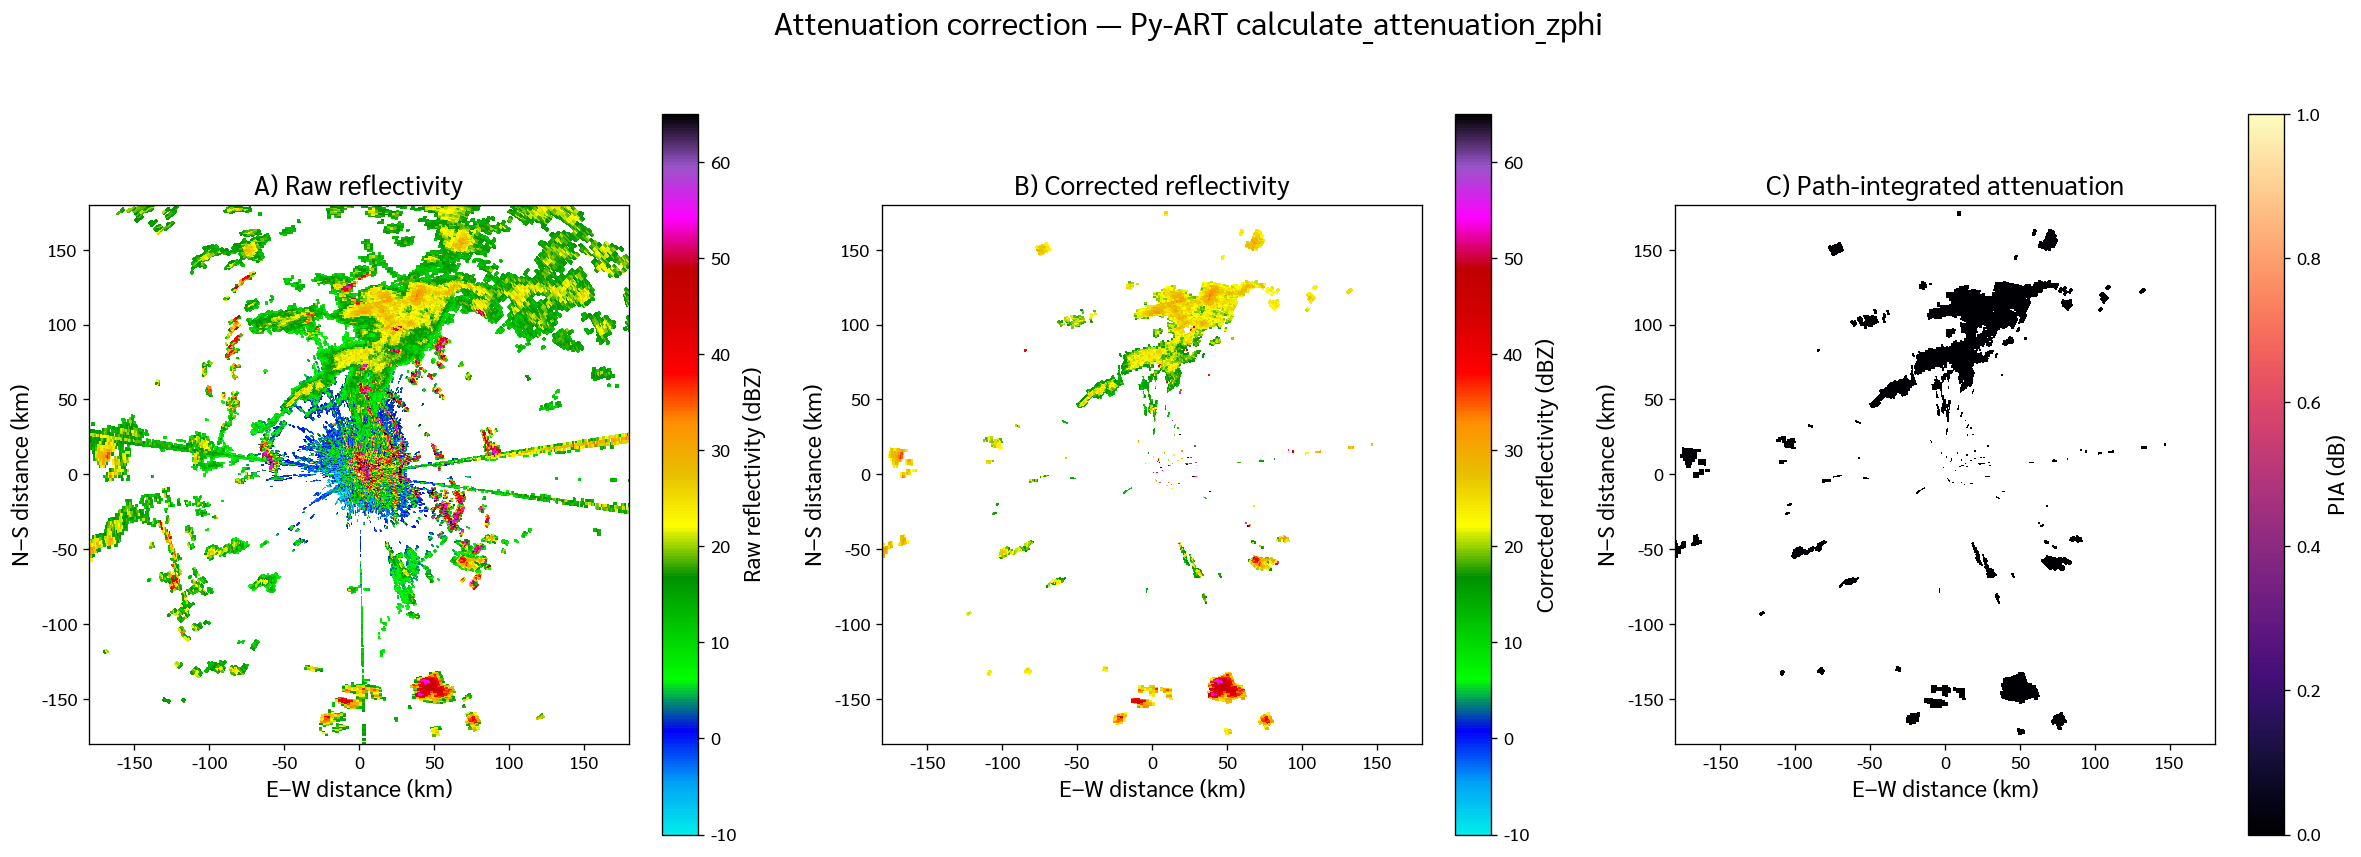

Saved: /content/drive/MyDrive/tmd_radar_course/1results/lesson07/figures/attenuation_before_after_PIA.png


In [ ]:
#@title พลอต reflectivity ก่อนและหลัง attenuation correction
figure, axes = plt.subplots(
    1,
    3,
    figsize=(20, 7),
)

radar_display = pyart.graph.RadarDisplay(
    radar
)

radar_display.plot_ppi(
    REFLECTIVITY,
    sweep=SWEEP,
    ax=axes[0],
    vmin=-10,
    vmax=65,
    cmap=REF_CMAP,
    colorbar_label="Raw reflectivity (dBZ)",
    title="A) Raw reflectivity",
)

radar_display.plot_ppi(
    CORRECTED_REFLECTIVITY_FIELD,
    sweep=SWEEP,
    ax=axes[1],
    vmin=-10,
    vmax=65,
    cmap=REF_CMAP,
    colorbar_label=(
        "Corrected reflectivity (dBZ)"
    ),
    title="B) Corrected reflectivity",
)

radar_display.plot_ppi(
    PIA_FIELD,
    sweep=SWEEP,
    ax=axes[2],
    vmin=0,
    vmax=max(
        1.0,
        min(
            15.0,
            float(
                np.nanpercentile(
                    pia_values_valid,
                    99,
                )
            )
            if pia_values_valid.size
            else 5.0,
        ),
    ),
    cmap="magma",
    colorbar_label="PIA (dB)",
    title="C) Path-integrated attenuation",
)

for axis in axes:
    axis.set_xlim(
        -MAX_DISPLAY_RANGE_KM,
        MAX_DISPLAY_RANGE_KM,
    )
    axis.set_ylim(
        -MAX_DISPLAY_RANGE_KM,
        MAX_DISPLAY_RANGE_KM,
    )
    axis.set_aspect("equal")
    axis.set_xlabel("E–W distance (km)")
    axis.set_ylabel("N–S distance (km)")

figure.suptitle(
    f"Attenuation correction — {ATTENUATION_METHOD}",
    fontsize=19,
    y=1.02,
)
figure.tight_layout()

attenuation_figure = (
    FIGURE_DIR
    / "attenuation_before_after_PIA.png"
)
figure.savefig(
    attenuation_figure,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print("Saved:", attenuation_figure)


## 🧊 16. Hydrometeor Classification

ใช้ Py-ART semi-supervised hydroclass ซึ่งคืน 9 hydrometeor classes:

| Code | Class |
|---:|---|
| 0 | Not classified |
| 1 | Aggregates |
| 2 | Ice crystals |
| 3 | Light rain |
| 4 | Rimed particles |
| 5 | Rain |
| 6 | Vertically oriented ice |
| 7 | Wet snow |
| 8 | Melting hail |
| 9 | Dry hail / high-density graupel |

Input ที่ใช้:

- corrected reflectivity
- corrected ZDR
- local KDP
- RHOHV
- mapped temperature

หาก official algorithm ไม่สำเร็จ จะใช้ rule-based fallback สำหรับการสาธิตเท่านั้น และบันทึกสถานะอย่างชัดเจน


In [ ]:
#@title ฟังก์ชัน pedagogical HID fallback
HID_CLASS_NAMES = {
    0: "Not classified",
    1: "Aggregates",
    2: "Ice crystals",
    3: "Light rain",
    4: "Rimed particles",
    5: "Rain",
    6: "Vertically oriented ice",
    7: "Wet snow",
    8: "Melting hail",
    9: "Dry hail / high-density graupel",
}

def pedagogical_hid_fallback(
    zh,
    zdr,
    kdp,
    rhohv,
    temperature,
    invalid_mask,
):
    hydro = np.zeros(
        zh.shape,
        dtype=np.int16,
    )

    valid = (
        ~invalid_mask
        & np.isfinite(zh)
        & np.isfinite(zdr)
        & np.isfinite(kdp)
        & np.isfinite(rhohv)
        & np.isfinite(temperature)
    )

    # ใช้ลำดับจาก class ทั่วไปไป class เฉพาะ
    hydro[
        valid
        & (temperature > 0)
        & (zh >= 10)
        & (zh < 30)
    ] = 3

    hydro[
        valid
        & (temperature > 0)
        & (zh >= 30)
    ] = 5

    hydro[
        valid
        & (temperature <= 0)
        & (temperature > -10)
        & (zh >= 25)
        & (rhohv >= 0.90)
    ] = 4

    hydro[
        valid
        & (temperature <= -5)
        & (zh >= 15)
        & (zh < 35)
        & (zdr <= 1.5)
    ] = 1

    hydro[
        valid
        & (temperature <= -10)
        & (zh < 30)
        & (zdr > 1.0)
    ] = 2

    hydro[
        valid
        & (temperature <= -10)
        & (zh < 35)
        & (zdr > 2.0)
    ] = 6

    hydro[
        valid
        & (np.abs(temperature) <= 2.0)
        & (rhohv < 0.97)
    ] = 7

    hydro[
        valid
        & (temperature > -5)
        & (zh >= 50)
        & (rhohv < 0.95)
        & (kdp >= 0.5)
    ] = 8

    hydro[
        valid
        & (temperature <= 0)
        & (zh >= 50)
        & (zdr < 2.0)
    ] = 9

    return hydro

HID_METHOD = None
HID_ERROR = None
HID_ENTROPY_AVAILABLE = False

try:
    hid_fields = (
        pyart.retrieve.hydroclass_semisupervised(
            radar,
            refl_field=(
                CORRECTED_REFLECTIVITY_FIELD
            ),
            zdr_field=CORRECTED_ZDR_FIELD,
            rhv_field=RHOHV,
            kdp_field="kdp_local",
            temp_field="temperature",
            iso0_field=None,
            hydro_field="hydroclass",
            entropy_field=(
                "hydroclass_entropy"
            ),
            radar_freq=(
                RADAR_FREQUENCY_HZ
            ),
            temp_ref="temperature",
            compute_entropy=True,
            output_distances=False,
            vectorize=True,
        )
    )

    hydro_dictionary = hid_fields[
        "hydro"
    ]
    hydro_array = np.ma.asarray(
        hydro_dictionary["data"]
    )
    hydro_dictionary["data"] = np.ma.array(
        hydro_array,
        mask=(
            np.ma.getmaskarray(
                hydro_array
            )
            | KDP_QC_MASK
        ),
    )

    radar.add_field(
        "hydroclass",
        hydro_dictionary,
        replace_existing=True,
    )

    if "entropy" in hid_fields:
        radar.add_field(
            "hydroclass_entropy",
            hid_fields["entropy"],
            replace_existing=True,
        )
        HID_ENTROPY_AVAILABLE = True

    HID_METHOD = (
        "Py-ART hydroclass_semisupervised"
    )

except Exception as error:
    HID_ERROR = repr(error)
    HID_METHOD = (
        "pedagogical rule-based fallback"
    )

    print(
        "Official hydroclass ไม่สำเร็จ "
        "จึงใช้ fallback:",
        error,
    )

    corrected_zh_values = np.ma.asarray(
        radar.fields[
            CORRECTED_REFLECTIVITY_FIELD
        ]["data"]
    ).filled(np.nan)
    corrected_zdr_values = np.ma.asarray(
        radar.fields[
            CORRECTED_ZDR_FIELD
        ]["data"]
    ).filled(np.nan)
    temperature_values = np.ma.asarray(
        radar.fields[
            "temperature"
        ]["data"]
    ).filled(np.nan)

    hydro_values = pedagogical_hid_fallback(
        corrected_zh_values,
        corrected_zdr_values,
        KDP_LOCAL_VALUES,
        RHOHV_VALUES,
        temperature_values,
        KDP_QC_MASK,
    )

    radar.add_field(
        "hydroclass",
        radar_field(
            hydro_values,
            units="unitless",
            long_name=(
                "pedagogical rule based hydrometeor class"
            ),
            standard_name=(
                "hydrometeor_classification"
            ),
            mask=KDP_QC_MASK,
        ),
        replace_existing=True,
    )

print("HID method:", HID_METHOD)
if HID_ERROR:
    print("HID error:", HID_ERROR)

HID method: Py-ART hydroclass_semisupervised


In [ ]:
#@title HID class statistics
hydro_data = np.ma.asarray(
    radar.fields["hydroclass"]["data"]
)
hydro_values = hydro_data.compressed()
hydro_values = hydro_values[
    np.isfinite(hydro_values)
].astype(int)

classified_values = hydro_values[
    hydro_values > 0
]

hid_rows = []
for class_code in range(10):
    count = int(
        np.sum(
            hydro_values == class_code
        )
    )
    hid_rows.append({
        "class_code": class_code,
        "class_name": HID_CLASS_NAMES[
            class_code
        ],
        "gates": count,
        "fraction_of_valid_pct": float(
            100 * count / hydro_values.size
        )
        if hydro_values.size
        else np.nan,
        "fraction_of_classified_pct": float(
            100 * count / classified_values.size
        )
        if (
            classified_values.size
            and class_code > 0
        )
        else np.nan,
    })

hid_class_df = pd.DataFrame(
    hid_rows
)
display(hid_class_df.round(3))

hid_class_df.to_csv(
    CSV_DIR / "HID_class_statistics.csv",
    index=False,
    encoding="utf-8-sig",
)

,class_code,class_name,gates,fraction_of_valid_pct,fraction_of_classified_pct
0,0,Not classified,0,0.000,NaN
1,1,Aggregates,295,1.328,1.328
2,2,Ice crystals,0,0.000,0.000
3,3,Light rain,11525,51.889,51.889
4,4,Rimed particles,318,1.432,1.432
5,5,Rain,1170,5.268,5.268
6,6,Vertically oriented ice,7075,31.854,31.854
7,7,Wet snow,975,4.390,4.390
8,8,Melting hail,34,0.153,0.153
9,9,Dry hail / high-density graupel,819,3.687,3.687


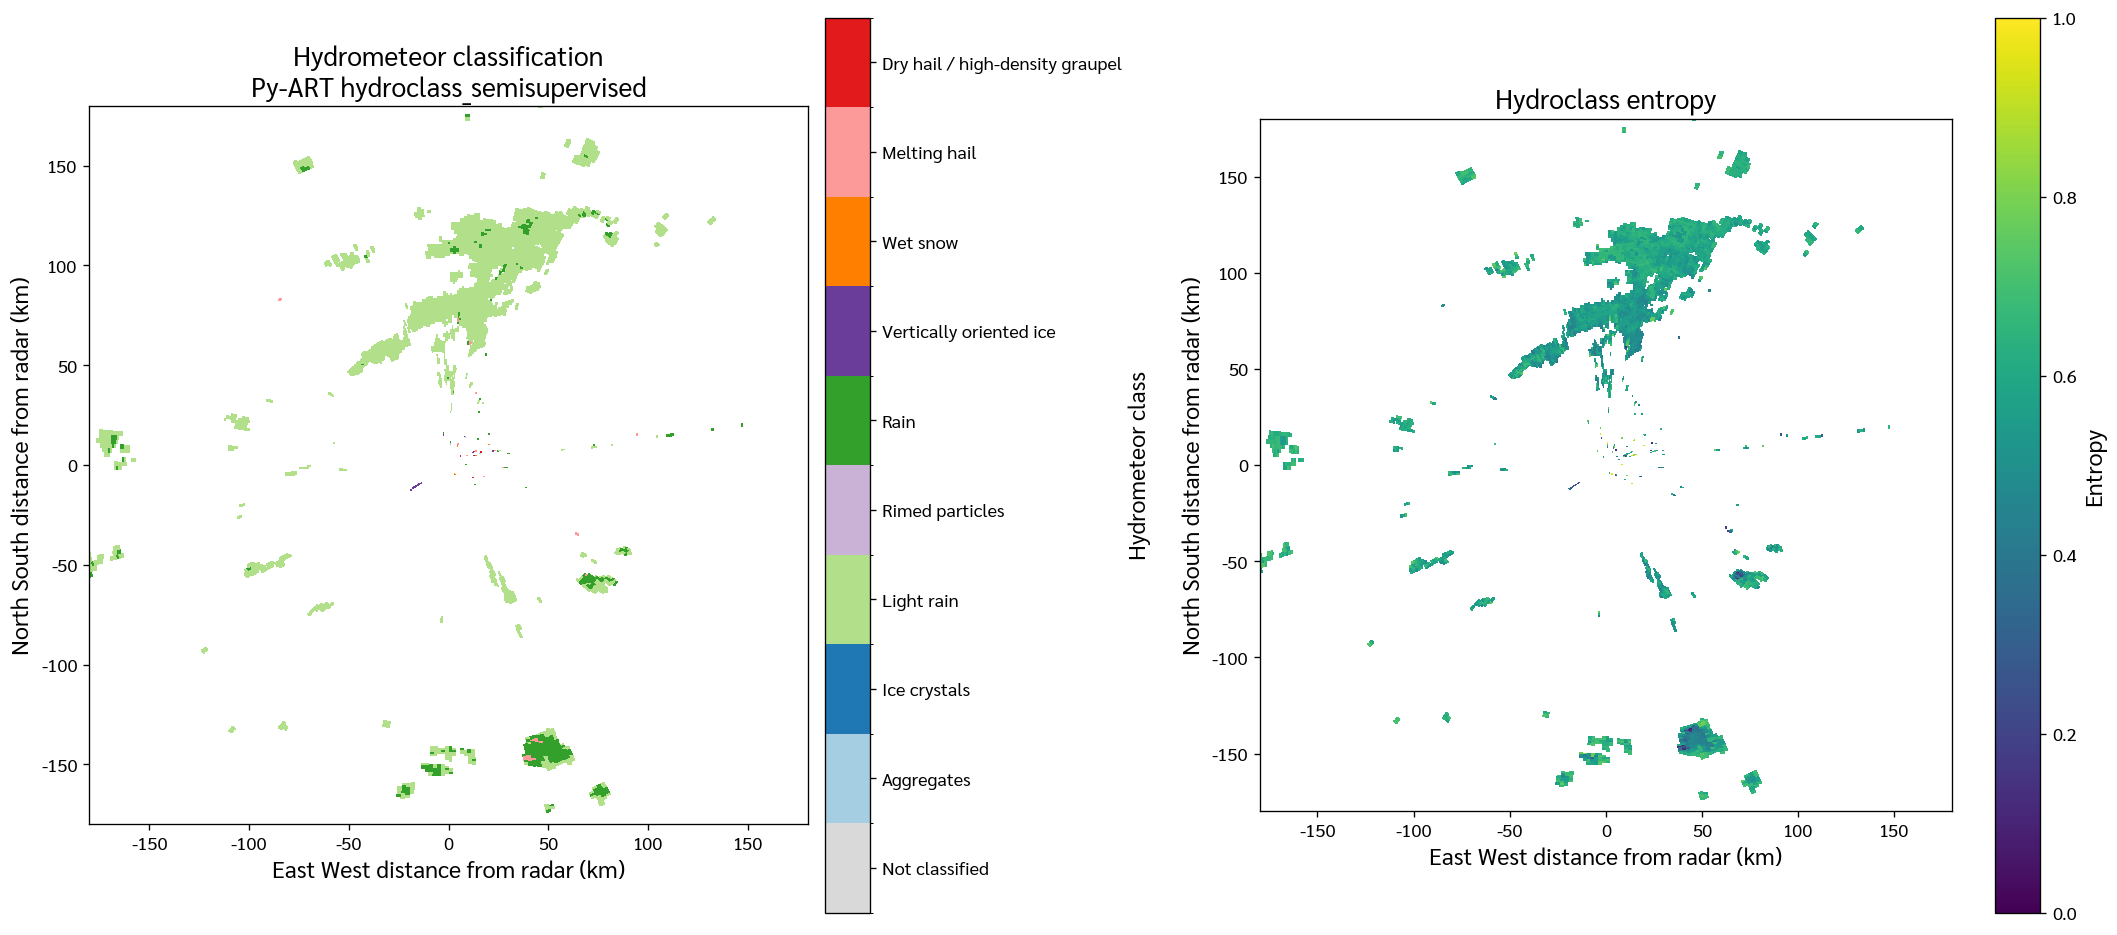

Saved: /content/drive/MyDrive/tmd_radar_course/1results/lesson07/figures/HID_and_entropy_PPI.png


In [ ]:
#@title พลอต HID และ entropy
HID_COLORS = [
    "#d9d9d9",  # 0 Not classified
    "#a6cee3",  # 1 Aggregates
    "#1f78b4",  # 2 Ice crystals
    "#b2df8a",  # 3 Light rain
    "#cab2d6",  # 4 Rimed particles
    "#33a02c",  # 5 Rain
    "#6a3d9a",  # 6 Vertically oriented ice
    "#ff7f00",  # 7 Wet snow
    "#fb9a99",  # 8 Melting hail
    "#e31a1c",  # 9 Dry hail / HDG
]
HID_CMAP = ListedColormap(
    HID_COLORS
)
HID_NORM = BoundaryNorm(
    np.arange(-0.5, 10.5, 1),
    HID_CMAP.N,
)

number_of_panels = (
    2
    if HID_ENTROPY_AVAILABLE
    else 1
)

figure, axes = plt.subplots(
    1,
    number_of_panels,
    figsize=(
        9 * number_of_panels,
        8,
    ),
)
axes = np.atleast_1d(
    axes
)

radar_display = pyart.graph.RadarDisplay(
    radar
)

radar_display.plot_ppi(
    "hydroclass",
    sweep=SWEEP,
    ax=axes[0],
    vmin=-0.5,
    vmax=9.5,
    cmap=HID_CMAP,
    norm=HID_NORM,
    colorbar_flag=False,
    title=(
        f"Hydrometeor classification\n"
        f"{HID_METHOD}"
    ),
)
axes[0].set_xlim(
    -MAX_DISPLAY_RANGE_KM,
    MAX_DISPLAY_RANGE_KM,
)
axes[0].set_ylim(
    -MAX_DISPLAY_RANGE_KM,
    MAX_DISPLAY_RANGE_KM,
)
axes[0].set_aspect("equal")

scalar_mappable = mpl.cm.ScalarMappable(
    norm=HID_NORM,
    cmap=HID_CMAP,
)
colorbar = figure.colorbar(
    scalar_mappable,
    ax=axes[0],
    ticks=range(10),
    pad=0.02,
)
colorbar.ax.set_yticklabels([
    HID_CLASS_NAMES[index]
    for index in range(10)
])
colorbar.set_label(
    "Hydrometeor class"
)

if HID_ENTROPY_AVAILABLE:
    radar_display.plot_ppi(
        "hydroclass_entropy",
        sweep=SWEEP,
        ax=axes[1],
        vmin=0,
        vmax=1,
        cmap="viridis",
        colorbar_label="Entropy",
        title="Hydroclass entropy",
    )
    axes[1].set_xlim(
        -MAX_DISPLAY_RANGE_KM,
        MAX_DISPLAY_RANGE_KM,
    )
    axes[1].set_ylim(
        -MAX_DISPLAY_RANGE_KM,
        MAX_DISPLAY_RANGE_KM,
    )
    axes[1].set_aspect("equal")

figure.tight_layout()

hid_figure = (
    FIGURE_DIR
    / "HID_and_entropy_PPI.png"
)
figure.savefig(
    hid_figure,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print("Saved:", hid_figure)


## 📋 17. สรุปสถานะอัลกอริทึม

ตารางนี้ทำให้ผู้ใช้ทราบอย่างชัดเจนว่า

- KDP ใช้วิธีใด
- Maesaka ถูกเรียกหรือไม่
- attenuation ใช้ Z–PHI หรือ fallback
- HID ใช้ official semi-supervised หรือ fallback
- sounding เป็น pedagogical mismatch


In [ ]:
#@title Algorithm status table
algorithm_status_df = pd.DataFrame([
    {
        "component": "PHIDP processing",
        "method": (
            "segment-wise unwrap + "
            "Savitzky-Golay smoothing"
        ),
        "success": True,
        "warning": None,
    },
    {
        "component": "KDP default",
        "method": (
            "0.5 × Savitzky-Golay "
            "PHIDP derivative"
        ),
        "success": True,
        "warning": (
            "Educational transparent method; "
            "validate against research-grade retrieval"
        ),
    },
    {
        "component": "KDP Maesaka",
        "method": (
            "Py-ART kdp_maesaka"
        ),
        "success": (
            maesaka_status["success"]
        ),
        "warning": (
            maesaka_status["error"]
            or "Disabled by default"
        ),
    },
    {
        "component": "Attenuation",
        "method": ATTENUATION_METHOD,
        "success": True,
        "warning": ATTENUATION_ERROR,
    },
    {
        "component": "HID",
        "method": HID_METHOD,
        "success": True,
        "warning": HID_ERROR,
    },
    {
        "component": "Temperature profile",
        "method": (
            "VTCC sounding mapped to PHS gates"
        ),
        "success": True,
        "warning": (
            "Spatially and temporally mismatched; "
            "pedagogical use only"
        ),
    },
])

display(algorithm_status_df)
algorithm_status_df.to_csv(
    CSV_DIR / "algorithm_status.csv",
    index=False,
    encoding="utf-8-sig",
)

,component,method,success,warning
0,PHIDP processing,segment-wise unwrap + Savitzky-Golay smoothing,True,None
1,KDP default,0.5 × Savitzky-Golay PHIDP derivative,True,Educational transparent method; validate again...
2,KDP Maesaka,Py-ART kdp_maesaka,False,Disabled by default
3,Attenuation,Py-ART calculate_attenuation_zphi,True,None
4,HID,Py-ART hydroclass_semisupervised,True,None
5,Temperature profile,VTCC sounding mapped to PHS gates,True,Spatially and temporally mismatched; pedagogic...



## 💾 18. ส่งออก processed CF/Radial และ metadata

Processed radar จะมีฟิลด์เพิ่มเติม เช่น

- `phidp_unwrapped`
- `phidp_filtered`
- `phidp_local_std`
- `kdp_local`
- `temperature`
- `specific_attenuation`
- `path_integrated_attenuation`
- `corrected_reflectivity_zphi`
- `corrected_zdr_zphi`
- `hydroclass`
- `hydroclass_entropy` เมื่อมี

ไฟล์นี้ใช้ต่อในบทที่ 08 QPE ได้


In [ ]:
#@title เขียน processed CF/Radial NetCDF
PROCESSED_RADAR_PATH = (
    NETCDF_DIR
    / "PHS_20180720_1000_polarimetric_processed.nc"
)

radar.metadata[
    "lesson07_processing_note"
] = (
    "Polarimetric teaching workflow: "
    "PHIDP QC, local KDP, attenuation, "
    "temperature mapping and HID"
)
radar.metadata[
    "sounding_warning"
] = (
    "VTCC sounding 00 UTC 24 Apr 2021 "
    "is not collocated with PHS radar "
    "20 Jul 2018; pedagogical use only"
)
radar.metadata[
    "attenuation_method"
] = ATTENUATION_METHOD
radar.metadata[
    "hid_method"
] = HID_METHOD

pyart.io.write_cfradial(
    str(PROCESSED_RADAR_PATH),
    radar,
)

radar_check = pyart.io.read(
    str(PROCESSED_RADAR_PATH)
)

print("Saved:", PROCESSED_RADAR_PATH)
print(
    "File size:",
    f"{PROCESSED_RADAR_PATH.stat().st_size / 1024**2:.2f} MB",
)
print(
    "Reopened fields:",
    len(radar_check.fields),
)
print(
    "Required output fields present:",
    all(
        field_name
        in radar_check.fields
        for field_name in [
            "phidp_filtered",
            "kdp_local",
            CORRECTED_REFLECTIVITY_FIELD,
            "hydroclass",
        ]
    ),
)

Saved: /content/drive/MyDrive/tmd_radar_course/1results/lesson07/netcdf/PHS_20180720_1000_polarimetric_processed.nc
File size: 15.18 MB
Reopened fields: 21
Required output fields present: True



## 🧾 19. บันทึกพารามิเตอร์และ sync ผลลัพธ์

ทุกพารามิเตอร์ที่มีผลต่อผลลัพธ์จะถูกบันทึกใน `lesson07_parameters.json`


In [ ]:
#@title บันทึก JSON และคัดลอก local diagnostics
parameter_record = {
    "notebook": (
        "07_polarimetric_QC_KDP_attenuation_HID.ipynb"
    ),
    "course_root": P.ROOT,
    "input_paths": {
        "radar": P.RADAR_1000,
        "sounding": P.SOUNDING,
    },
    "selected_fields": SELECTED_FIELDS,
    "radar": {
        "latitude": RADAR_LAT,
        "longitude": RADAR_LON,
        "altitude_m_msl": RADAR_ALT_MSL_M,
        "gate_spacing_km": GATE_SPACING_KM,
        "nominal_frequency_hz": (
            NOMINAL_C_BAND_FREQUENCY_HZ
        ),
    },
    "qc": {
        "minimum_reflectivity_dbz": (
            QC_MIN_REFLECTIVITY_DBZ
        ),
        "minimum_rhohv": QC_MIN_RHOHV,
        "minimum_zdr_db": QC_MIN_ZDR_DB,
        "maximum_zdr_db": QC_MAX_ZDR_DB,
        "maximum_phidp_std_deg": (
            QC_MAX_PHIDP_STD_DEG
        ),
        "phidp_std_window_gates": (
            PHIDP_STD_WINDOW_GATES
        ),
        "phidp_smooth_window_gates": (
            PHIDP_SMOOTH_WINDOW_GATES
        ),
    },
    "kdp": {
        "default_method": (
            "Savitzky-Golay derivative"
        ),
        "derivative_window_gates": (
            KDP_DERIVATIVE_WINDOW_GATES
        ),
        "valid_min_deg_per_km": (
            KDP_VALID_MIN
        ),
        "valid_max_deg_per_km": (
            KDP_VALID_MAX
        ),
        "maesaka": maesaka_status,
    },
    "sounding": {
        "description": (
            "VTCC Chiang Mai, 00 UTC "
            "24 April 2021"
        ),
        "use": "pedagogical only",
        "isotherm_heights_m_msl": {
            str(row["temperature_c"]): (
                row["height_m_msl"]
            )
            for row in isotherm_rows
        },
    },
    "attenuation": {
        "method": ATTENUATION_METHOD,
        "error": ATTENUATION_ERROR,
        "corrected_reflectivity_field": (
            CORRECTED_REFLECTIVITY_FIELD
        ),
        "corrected_zdr_field": (
            CORRECTED_ZDR_FIELD
        ),
    },
    "hid": {
        "method": HID_METHOD,
        "error": HID_ERROR,
        "entropy_available": (
            HID_ENTROPY_AVAILABLE
        ),
        "classes": HID_CLASS_NAMES,
    },
    "processed_radar": (
        str(PROCESSED_RADAR_PATH)
    ),
    "notes": [
        "The sounding is not temporally or spatially collocated with the radar event.",
        "The local KDP derivative is an educational transparent retrieval.",
        "ZDR bias and system PHIDP offset have not been independently calibrated.",
        "Fallback attenuation and fallback HID are not intended for publication.",
        "Research use requires radar-specific calibration and validation.",
    ],
}

PARAMETER_JSON = (
    LESSON07_DIR
    / "lesson07_parameters.json"
)
with PARAMETER_JSON.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        parameter_record,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Saved:", PARAMETER_JSON)
print("\nLesson07 files:")
for path in sorted(
    LESSON07_DIR.rglob("*")
):
    if path.is_file():
        print("  •", path.relative_to(LESSON07_DIR))

Saved: /content/drive/MyDrive/tmd_radar_course/1results/lesson07/lesson07_parameters.json

Lesson07 files:
  • csv/HID_class_statistics.csv
  • csv/algorithm_status.csv
  • csv/attenuation_summary.csv
  • csv/base_qc_reasons.csv
  • csv/kdp_comparison.csv
  • csv/maesaka_status.csv
  • csv/polarimetric_field_inventory.csv
  • csv/polarimetric_qc_summary.csv
  • csv/representative_ray_diagnostics.csv
  • csv/sounding_isotherm_heights.csv
  • csv/sounding_temperature_profile.csv
  • figures/HID_and_entropy_PPI.png
  • figures/PHIDP_QC_and_KDP_PPI.png
  • figures/attenuation_before_after_PIA.png
  • figures/raw_dualpol_PPI_panel.png
  • figures/representative_ray_PHIDP_KDP_diagnostics.png
  • figures/sounding_temperature_and_isotherms.png
  • lesson07_parameters.json
  • netcdf/PHS_20180720_1000_polarimetric_processed.nc



## 📝 20. แบบฝึกหัด

### แบบฝึกหัดที่ 1 — RHOHV threshold

ทดลอง

```python
QC_MIN_RHOHV = 0.70, 0.80, 0.85, 0.90, 0.95
```

เปรียบเทียบ

- valid gates
- PHIDP continuity
- KDP extreme values
- HID class proportions

### แบบฝึกหัดที่ 2 — PHIDP smoothing

ทดลอง window 5, 9, 13 และ 21 gates แล้วเปรียบเทียบ

- ความเรียบของ PHIDP
- maximum KDP
- area ที่ KDP ≥1 deg km\(^{-1}\)
- storm detail ที่สูญหาย

### แบบฝึกหัดที่ 3 — PHIDP standard deviation

ทดลอง threshold 8°, 12°, 20° และ 30° แล้วอธิบาย trade-off ระหว่าง noise removal กับ data retention

### แบบฝึกหัดที่ 4 — KDP methods

เปิด `RUN_MAESAKA = True` แล้วเปรียบเทียบ `kdp_local` กับ `kdp_maesaka`

- correlation
- MAE
- computation time
- negative values
- spatial continuity

### แบบฝึกหัดที่ 5 — Attenuation

เปรียบเทียบ raw กับ corrected reflectivity ในแนว ray ที่มี PIA สูงสุด

ตอบว่า correction เพิ่มขึ้นตามระยะอย่างสมเหตุสมผลหรือไม่

### แบบฝึกหัดที่ 6 — Sounding sensitivity

เลื่อน temperature profile ทั้งชุด ±2 °C แล้วเปรียบเทียบ HID โดยเฉพาะ

- wet snow
- melting hail
- dry hail / high-density graupel

### แบบฝึกหัดที่ 7 — ตรวจข้อจำกัด

อธิบายเหตุผลอย่างน้อย 5 ข้อที่ทำให้ HID จาก Notebook นี้ยังไม่ควรใช้ยืนยันว่ามีลูกเห็บเกิดขึ้นจริง


In [ ]:
#@title พื้นที่ทดลองของนิสิต
STUDENT_MIN_RHOHV = 0.85
STUDENT_MAX_PHIDP_STD_DEG = 20.0
STUDENT_SMOOTH_WINDOW_GATES = 9
STUDENT_KDP_WINDOW_GATES = 9

print("Student parameters")
print("Minimum RHOHV          :", STUDENT_MIN_RHOHV)
print(
    "Maximum PHIDP SD       :",
    STUDENT_MAX_PHIDP_STD_DEG,
    "degrees",
)
print(
    "PHIDP smoothing window :",
    STUDENT_SMOOTH_WINDOW_GATES,
    "gates",
)
print(
    "KDP derivative window  :",
    STUDENT_KDP_WINDOW_GATES,
    "gates",
)

# TODO:
# 1. สร้าง BASE_QC_MASK ใหม่ด้วย STUDENT_MIN_RHOHV
# 2. เรียก process_phidp_volume ใหม่
# 3. เปรียบเทียบ valid fraction, KDP percentile และภาพ PPI
# 4. บันทึกผลใน DIAGNOSTIC_DIR

# ----- โครงเริ่มต้น (เติมส่วนที่ขาดตามคำแนะนำด้านบน) -----

student_zh_bad = ZH_BAD  # ใช้ mask เดิมจากด้านบนได้เลย
student_base_qc_mask = (
    student_zh_bad
    | ZDR_BAD
    | PHIDP_BAD
    | RHOHV_BAD
    | (ZH_VALUES < QC_MIN_REFLECTIVITY_DBZ)
    | (RHOHV_VALUES < STUDENT_MIN_RHOHV)  # <-- ใช้ค่าที่นิสิตตั้งเอง
    | (ZDR_VALUES < QC_MIN_ZDR_DB)
    | (ZDR_VALUES > QC_MAX_ZDR_DB)
)

# TODO 2: เรียก process_phidp_volume(...) ด้วย student_base_qc_mask
# student_phidp_unwrapped, student_phidp_filtered, student_phidp_std, student_kdp_local, student_diag = (
#     process_phidp_volume(
#         PHIDP_VALUES,
#         student_base_qc_mask,
#         gate_spacing_km=GATE_SPACING_KM,
#         smooth_window=STUDENT_SMOOTH_WINDOW_GATES,
#         derivative_window=STUDENT_KDP_WINDOW_GATES,
#         std_window=PHIDP_STD_WINDOW_GATES,
#     )
# )

# TODO 3: เทียบ valid fraction และ percentile กับผลลัพธ์หลักของบทนี้
# print("baseline valid fraction:", np.isfinite(KDP_LOCAL_VALUES).mean())
# print("student valid fraction :", np.isfinite(student_kdp_local).mean())

# TODO 4: บันทึกผลเปรียบเทียบเป็น CSV ใน DIAGNOSTIC_DIR
# pd.DataFrame([...]).to_csv(DIAGNOSTIC_DIR / "student_experiment.csv", index=False)


Student parameters
Minimum RHOHV          : 0.85
Maximum PHIDP SD       : 20.0 degrees
PHIDP smoothing window : 9 gates
KDP derivative window  : 9 gates



---
## 🎯 สรุป

- Polarimetric processing ต้องเริ่มจาก field audit และ QC
- RHOHV ต่ำไม่ได้หมายถึง clutter เสมอไป
- PHIDP ต้องตรวจ discontinuity, local variability และ valid segments
- \(K_{DP}\) คือครึ่งหนึ่งของ radial derivative ของ propagation PHIDP
- Smoothing window มีผลโดยตรงต่อ noise และ spatial detail
- Maesaka KDP เป็น variational retrieval ที่มีสมมติฐานและต้นทุนการคำนวณ
- C-band attenuation correction ต้องใช้ PHIDP ที่มีคุณภาพและ radar-specific validation
- Temperature profile ช่วยแยก liquid, melting และ ice regimes ใน HID
- Sounding ตัวอย่างในหลักสูตรไม่ตรงกับเหตุการณ์ PHS และใช้เพื่อสาธิตเท่านั้น
- HID เป็น probabilistic/algorithmic classification ไม่ใช่การยืนยันลูกเห็บภาคพื้น
- Processed CF/Radial จากบทนี้จะใช้ต่อในบทที่ 08 QPE

**บทถัดไป — บทที่ 08:** Radar QPE จาก \(R(Z)\), \(R(K_{DP})\) และ polarimetric estimators
